https://www.kaggle.com/datasets/parampratap/ecommerce-dataset?resource=download

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

In [132]:
df_comp = pd.read_csv('companies.csv')#done
df_metrics = pd.read_csv('company_metrics.csv')#done
df_dict = pd.read_csv('data_dictionary.csv') #just a full schema documentation and column definitions.
df_ecommerce = pd.read_csv('ecommerce_index.csv')
df_fin = pd.read_csv('financials_annual.csv')
df_macro = pd.read_csv('macro_indicators.csv')
df_stick = pd.read_csv('prices_daily.csv')

**Data set description**

The distinctive characteristic of a chosen data structure is in the composite dataset assembled from several independent sources that makes the analysis more comprehensive. The final dataset was created by merging multiple tables containing different types of information

In [133]:
print(len(df_comp['company_id'].unique()))
print(len(df_metrics['company_id'].unique()))
f = True
for x in df_comp['company_id'].unique():
    if x not in df_metrics['company_id'].unique() :
        f = False
        break
print(f)

43
43
True


In [10]:
df_comp.head()

,company_id,name,ticker,exchange,reporting_currency,country_code,region,segment,wikipedia_title,wikidata_qid,...,founded_date,headquarters,founders,industry,employees,employees_year,website,wiki_extract,wiki_url,wiki_thumbnail
0,amazon,Amazon.com,AMZN,NASDAQ,USD,US,North America,Marketplace + Cloud,Amazon (company),Q3884,...,1994-07-05,Seattle,Jeff Bezos,retail,1500000.0,2023.0,https://www.amazon.it/,"Amazon.com, Inc. is an American multinational ...",https://en.wikipedia.org/wiki/Amazon_(company),https://upload.wikimedia.org/wikipedia/commons...
1,ebay,eBay,EBAY,NASDAQ,USD,US,North America,C2C Marketplace,EBay,Q58024,...,1995-09-03,San Jose,Pierre Omidyar,e-commerce,12600.0,2016.0,https://www.ebay.com,eBay Inc. is an American multinational e-comme...,https://en.wikipedia.org/wiki/EBay,https://upload.wikimedia.org/wikipedia/commons...
2,etsy,Etsy,ETSY,NASDAQ,USD,US,North America,Handmade Marketplace,Etsy,Q1353939,...,2005-06-18,Dumbo,NaN,e-commerce,NaN,NaN,https://www.etsy.com/,"Etsy, Inc. is an American e-commerce company f...",https://en.wikipedia.org/wiki/Etsy,https://upload.wikimedia.org/wikipedia/commons...
3,shopify,Shopify,SHOP,NYSE,USD,CA,North America,E-commerce SaaS,Shopify,Q7501150,...,2006-00-00,Ottawa,Tobias Lütke,e-commerce,8300.0,2023.0,https://www.shopify.com,"Shopify Inc., stylized as shopify, is a Canadi...",https://en.wikipedia.org/wiki/Shopify,NaN
4,wayfair,Wayfair,W,NYSE,USD,US,North America,Home Goods,Wayfair,Q3540193,...,2002-00-00,Boston,NaN,e-commerce,NaN,NaN,https://www.wayfair.com/,Wayfair Inc. is an American multinational e-co...,https://en.wikipedia.org/wiki/Wayfair,https://upload.wikimedia.org/wikipedia/commons...


In [13]:
df_comp.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   company_id            43 non-null     str    
 1   name                  43 non-null     str    
 2   ticker                43 non-null     str    
 3   exchange              43 non-null     str    
 4   reporting_currency    43 non-null     str    
 5   country_code          43 non-null     str    
 6   region                43 non-null     str    
 7   segment               43 non-null     str    
 8   wikipedia_title       43 non-null     str    
 9   wikidata_qid          43 non-null     str    
 10  wiki_title_canonical  41 non-null     str    
 11  founded_date          39 non-null     str    
 12  headquarters          38 non-null     str    
 13  founders              27 non-null     str    
 14  industry              35 non-null     str    
 15  employees             6 non-null    

In [11]:
df_metrics.head()

,company_id,ticker,country_code,region,segment,history_start,history_end,trading_days,first_close,last_close,...,latest_fiscal_year,total_revenue,net_income,operating_income,total_assets,free_cash_flow,net_margin,operating_margin,revenue_cagr,revenue_cagr_years
0,affirm,AFRM,US,North America,BNPL,2021-01-13,2026-05-13,1339,96.364998,63.529999,...,2025,3.224412e+09,5.218600e+07,3.379930e+08,1.115493e+10,6.017200e+08,0.016185,0.104823,0.336949,3
1,alibaba,BABA,CN,Greater China,Marketplace + Cloud,2015-01-02,2026-05-13,2857,98.388405,145.809998,...,2025,9.963470e+11,1.301090e+11,1.470760e+11,1.804227e+12,7.753700e+10,0.130586,0.147615,0.053117,3
2,allegro,ALE.WA,PL,Europe,Marketplace,2020-10-13,2026-05-13,1395,80.000000,NaN,...,2025,1.145820e+10,1.517100e+09,2.161500e+09,1.972120e+10,1.852300e+09,0.132403,0.188642,0.083625,3
3,amazon,AMZN,US,North America,Marketplace + Cloud,2015-01-02,2026-05-13,2857,15.426000,270.130005,...,2025,7.169240e+11,7.767000e+10,7.997500e+10,8.180420e+11,7.695000e+09,0.108338,0.111553,0.117313,3
4,ao,AO.L,GB,Europe,Appliances,2015-01-02,2026-05-13,2870,285.600006,85.900002,...,2025,1.137600e+09,1.050000e+07,4.390000e+07,4.266000e+08,4.910000e+07,0.009230,0.038590,-0.059694,3


In [12]:
df_metrics.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company_id             43 non-null     str    
 1   ticker                 43 non-null     str    
 2   country_code           43 non-null     str    
 3   region                 43 non-null     str    
 4   segment                43 non-null     str    
 5   history_start          43 non-null     str    
 6   history_end            43 non-null     str    
 7   trading_days           43 non-null     int64  
 8   first_close            43 non-null     float64
 9   last_close             30 non-null     float64
 10  cumulative_return      30 non-null     float64
 11  cagr                   30 non-null     float64
 12  annualized_volatility  43 non-null     float64
 13  max_drawdown           43 non-null     float64
 14  all_time_high          43 non-null     float64
 15  all_time_high_date 

In [134]:
df = df_comp.merge(
    df_metrics,
    on="company_id",
    how="inner"
)
print(df.shape)
print(df.head(5))

(43, 48)
  company_id        name ticker_x exchange reporting_currency country_code_x  \
0     amazon  Amazon.com     AMZN   NASDAQ                USD             US   
1       ebay        eBay     EBAY   NASDAQ                USD             US   
2       etsy        Etsy     ETSY   NASDAQ                USD             US   
3    shopify     Shopify     SHOP     NYSE                USD             CA   
4    wayfair     Wayfair        W     NYSE                USD             US   

        region_x             segment_x   wikipedia_title wikidata_qid  ...  \
0  North America   Marketplace + Cloud  Amazon (company)        Q3884  ...   
1  North America       C2C Marketplace              EBay       Q58024  ...   
2  North America  Handmade Marketplace              Etsy     Q1353939  ...   
3  North America       E-commerce SaaS           Shopify     Q7501150  ...   
4  North America            Home Goods           Wayfair     Q3540193  ...   

  latest_fiscal_year total_revenue    net

**Statistecs**

In [135]:
macro_raw_wide = (
    df_macro
    .pivot_table(
        index=["country_code", "year"],
        columns="indicator_name",
        values="value"
    )
    .reset_index()
)

ищем выбросы

q1 — значение, ниже которого находится 25% наблюдений;
q3 — значение, ниже которого находится 75% наблюдений.

Например, если:

Q1 = 10
Q3 = 30

то центральные 50% данных находятся примерно между 10 и 30.

In [136]:
def find_outliers(series):
    series = series.dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = series[(series < lower) | (series > upper)]

    return outliers, lower, upper

In [ ]:
def outlier_scan(dataframe):
    numeric_cols = dataframe.select_dtypes(include=np.number).columns #выбираются только чилочисленные значения

    result = []

    for col in numeric_cols: #рассмотрим каждую колонку в датасете
        outliers, lower_bound, upper_bound = find_outliers(dataframe[col]) # возвращает результаты выбросов, верхнюю и нижнюю границу

        non_null_count = dataframe[col].dropna().shape[0] #необходимо чтобы выбросы считались на реальных значениях

        result.append({
            "column": col,
            "non_null_count": non_null_count,
            "outlier_count": len(outliers),
            "outlier_share": len(outliers) / non_null_count if non_null_count > 0 else np.nan,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        })

    return (
        pd.DataFrame(result)
        .sort_values("outlier_count", ascending=False)
        .reset_index(drop=True)
    )

In [138]:
outliers_df = outlier_scan(df)
outliers_df.head()

,column,non_null_count,outlier_count,outlier_share,lower_bound,upper_bound
0,total_assets,43,9,0.209302,-1.150655e+11,2.095544e+11
1,all_time_high,43,9,0.209302,-7.922250e+02,1.612935e+03
2,net_income,43,8,0.186047,-4.021049e+09,7.196391e+09
3,total_revenue,43,7,0.162791,-9.806339e+10,1.816602e+11
4,free_cash_flow,43,7,0.162791,-5.767718e+09,9.775930e+09


Column with the most outliers: total_assets


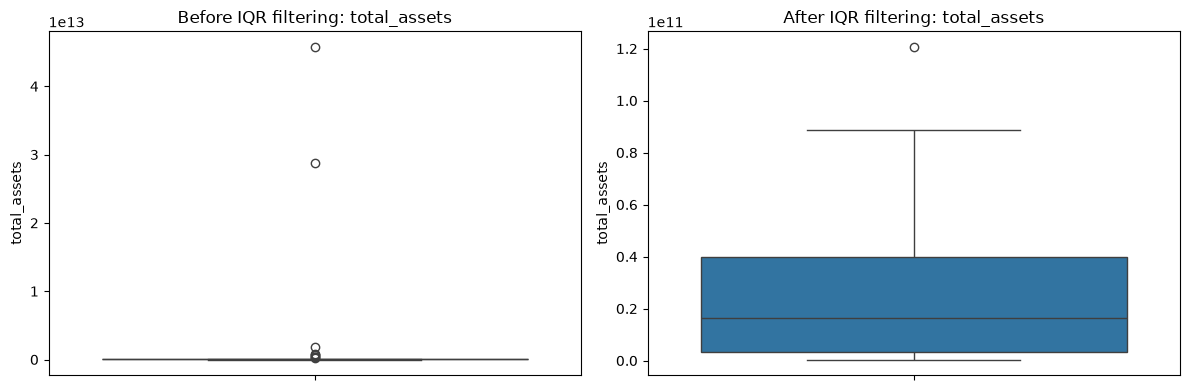

In [215]:
worst_col = outliers_df.iloc[0]["column"]
print("Column with the most outliers:", worst_col)

outliers, lower_bound, upper_bound = find_outliers(df[worst_col])

before = df[worst_col].dropna()
after = before[
    (before >= lower_bound) &
    (before <= upper_bound)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=before, ax=axes[0])
axes[0].set_title(f"Before IQR filtering: {worst_col}")

sns.boxplot(y=after, ax=axes[1])
axes[1].set_title(f"After IQR filtering: {worst_col}")

plt.tight_layout()
plt.show()

1. Линия внутри коробки — медиана

    Это значение, которое делит данные пополам:
    
    50% значений ниже медианы,50% выше
    
    На правом графике медиана total_assets примерно около 0.16⋅10^11
    
    то есть около: 1.6⋅10^10 - примерно 16 млрд.

2. Нижняя и верхняя границы коробки — Q1 и Q3
	​Нижняя граница коробки: Q1 - ниже неё находится 25% данных.

    Верхняя граница: Q3 - ниже неё находится 75% данных.

    Сама коробка содержит центральные 50% наблюдений:

    IQR=Q3−Q1
	​
Чем выше коробка, тем сильнее разбросана центральная половина данных.

На правом графике:

* основное распределение стало хорошо видно;
* медиана находится ближе к нижней границе коробки;
* верхняя половина коробки длиннее нижней;
* верхний ус намного длиннее нижнего;
* всё ещё осталась одна точка выше верхнего уса.

Это указывает на правостороннюю асимметрию: большинство значений относительно небольшие, но есть компании с гораздо более крупными активами.

Но после удаления экстремальных значений:

* Q1 изменился;
* Q3изменился;
* IQR изменился;

новые границы стали другими.

Поэтому значение, которое не было выбросом по первоначальным границам, может стать выбросом по пересчитанным границам.

То есть boxplot справа заново вычисляет IQR уже для очищенной выборки.

То есть:

* нижний ус — минимальное наблюдение, которое не меньше Q1−1.5IQR;
* верхний ус — максимальное наблюдение, которое не больше Q3+1.5IQR.

Пример:

    Q1=10,Q3=30,IQR=20

Тогда допустимые границы:

* 10−1.5⋅20=−20
* 30+1.5⋅20=60

Но если реальные значения заканчиваются на 52, верхний ус будет на 52, а не на 60.

    а вот границы коробки - это уже квартили

In [140]:
outliers_fin = outlier_scan(df_fin)
outliers_fin.head()

,column,non_null_count,outlier_count,outlier_share,lower_bound,upper_bound
0,free_cash_flow,172,42,0.244186,-4.005260e+09,6.306768e+09
1,net_income,172,41,0.238372,-3.812812e+09,5.456488e+09
2,operating_income,172,39,0.226744,-3.996162e+09,6.119298e+09
3,capex,172,34,0.197674,-3.005475e+09,1.659285e+09
4,total_assets,172,33,0.191860,-1.090278e+11,1.944906e+11


Column with the most outliers: free_cash_flow


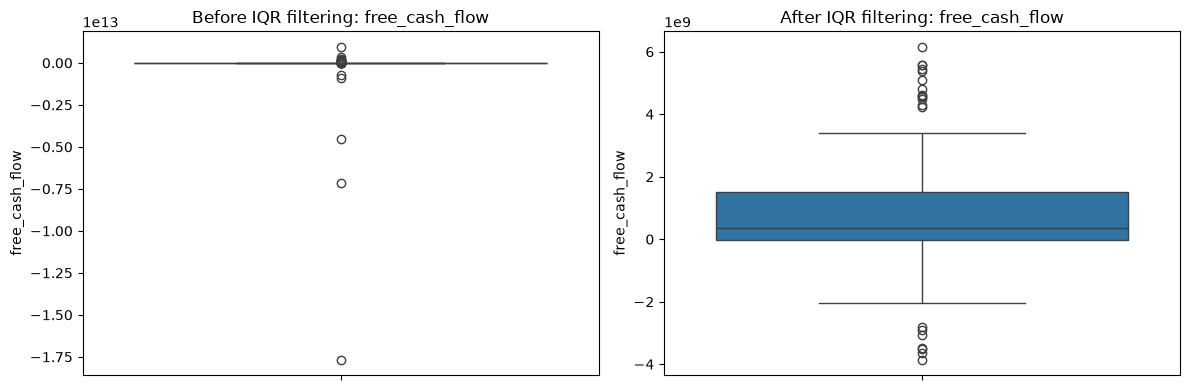

In [141]:
worst_col = outliers_fin.iloc[0]["column"]
print("Column with the most outliers:", worst_col)

outliers, lower_bound, upper_bound = find_outliers(df_fin[worst_col])

before = df_fin[worst_col].dropna()
after = before[
    (before >= lower_bound) &
    (before <= upper_bound)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=before, ax=axes[0])
axes[0].set_title(f"Before IQR filtering: {worst_col}")
axes[0].set_ylabel(worst_col)

sns.boxplot(y=after, ax=axes[1])
axes[1].set_title(f"After IQR filtering: {worst_col}")
axes[1].set_ylabel(worst_col)

plt.tight_layout()
plt.show()

In [142]:
outliers_macro = outlier_scan(macro_raw_wide)
outliers_macro.head()

,column,non_null_count,outlier_count,outlier_share,lower_bound,upper_bound
0,population_total,195,30,0.153846,-3.066715e+08,6.252613e+08
1,gdp_total_usd,180,27,0.150000,-3.100283e+12,8.717227e+12
2,fdi_inflow_pct_gdp,195,17,0.087179,-1.457472e+00,5.831336e+00
3,internet_users_pct,197,15,0.076142,2.468515e+01,1.297404e+02
4,account_ownership_pct_adult,65,4,0.061538,4.662242e+01,1.290403e+02


Column with the most outliers: population_total


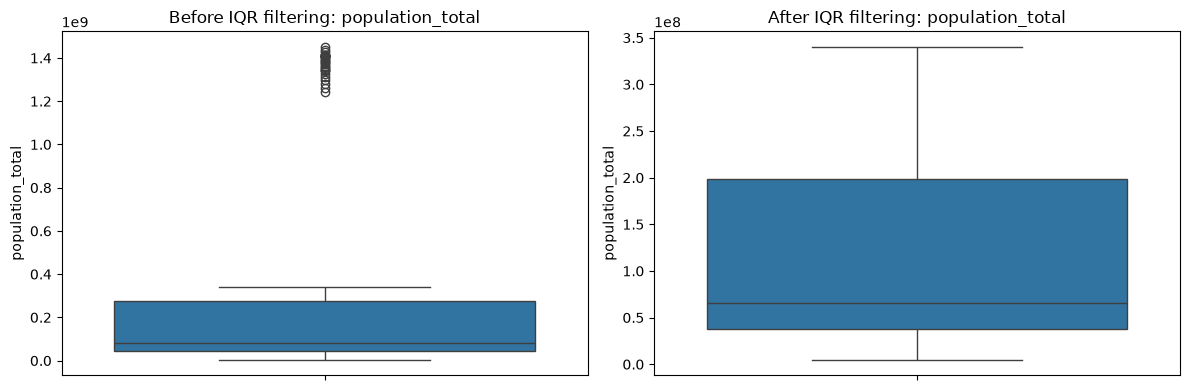

In [143]:
worst_col = outliers_macro.iloc[0]["column"]
print("Column with the most outliers:", worst_col)

outliers, lower_bound, upper_bound = find_outliers(macro_raw_wide[worst_col])

before = macro_raw_wide[worst_col].dropna()
after = before[
    (before >= lower_bound) &
    (before <= upper_bound)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=before, ax=axes[0])
axes[0].set_title(f"Before IQR filtering: {worst_col}")
axes[0].set_ylabel(worst_col)

sns.boxplot(y=after, ax=axes[1])
axes[1].set_title(f"After IQR filtering: {worst_col}")
axes[1].set_ylabel(worst_col)

plt.tight_layout()
plt.show()

In [ ]:
def quick_eda(dataframe, name="Dataset"):
    numeric_cols = dataframe.select_dtypes(include=np.number).columns
    categorical_cols = dataframe.select_dtypes(exclude=np.number).columns

    total_missing = dataframe.isna().sum().sum()

    missing_top = (
        dataframe
        .isna()
        .sum()
        .sort_values(ascending=False)
        .head(20)
        .reset_index()
    )
    missing_top.columns = ["column", "missing_count"]
    missing_top["missing_share"] = (
        missing_top["missing_count"] / len(dataframe)
    ).round(3)

    skew_top = (
        dataframe[numeric_cols]
        .skew() #skewness — коэффициент асимметрии, пол.знач. - длинныйхвост вправо, отриц. - слева
        .abs() #Так функция ищет наиболее сильно скошенные распределения независимо от направления перекоса.
        .sort_values(ascending=False)
        .head(20)
        .reset_index()
    )
    skew_top.columns = ["column", "abs_skewness"]

    if len(numeric_cols) >= 2: #корреляцию можно считать только при наличии хотя бы двух числовых столбцов
        corr = dataframe[numeric_cols].corr().abs() #здесь смотрим просто силу связи

        upper = corr.where(
            np.triu(np.ones(corr.shape), k=1).astype(bool) #оставляет верхнюю часть главной диагонали без самой диагонали
        )

        corr_pairs = (
            upper
            .stack() #превращает матрицу в длинную таблицу
            .sort_values(ascending=False)
            .head(20)
            .reset_index() #чтобы после сортировки или преобразования вернуть нормальный последовательный индекс
        )
        corr_pairs.columns = ["column_1", "column_2", "abs_correlation"]
    else:
        corr_pairs = pd.DataFrame(
            columns=["column_1", "column_2", "abs_correlation"]
        )

    print("=" * 70)
    print(f"QUICK EDA REPORT: {name}")
    print("=" * 70)
    print(f"Shape: {dataframe.shape[0]} rows × {dataframe.shape[1]} columns")
    print(f"Numeric columns: {len(numeric_cols)}")
    print(f"Categorical columns: {len(categorical_cols)}")
    print(f"Total missing values: {total_missing}")
    print("-" * 70)

    print("Top 3 columns with missing values:")
    display(missing_top)

    print("Top 3 most skewed numeric columns:")
    display(skew_top)

    print("Top 3 most correlated numeric pairs:")
    display(corr_pairs)

    print("\n")

In [145]:
quick_eda(df, "Merged companies + metrics")
quick_eda(df_fin, "Annual financials")
quick_eda(macro_raw_wide, "Macro indicators")

QUICK EDA REPORT: Merged companies + metrics
Shape: 43 rows × 48 columns
Numeric columns: 22
Categorical columns: 26
Total missing values: 195
----------------------------------------------------------------------
Top 3 columns with missing values:


,column,missing_count,missing_share
0,employees,37,0.860
1,employees_year,37,0.860
2,founders,16,0.372
3,wiki_thumbnail,15,0.349
4,cumulative_return,13,0.302
5,cagr,13,0.302
6,return_1y,13,0.302
7,last_close,13,0.302
8,return_90d,13,0.302
9,industry,8,0.186


Top 3 most skewed numeric columns:


,column,abs_skewness
0,total_revenue,6.304346
1,net_income,6.119750
2,free_cash_flow,5.725788
3,total_assets,4.819691
4,operating_income,4.423137
5,last_close,3.688779
6,cumulative_return,3.539576
7,all_time_high,2.960067
8,first_close,2.514489
9,employees,2.316834


Top 3 most correlated numeric pairs:


...

Top 3 most skewed numeric columns:


,column,abs_skewness
0,capex,12.289764
1,operating_income,11.460575
2,ebitda,10.923170
3,net_income,10.841558
4,free_cash_flow,10.263975
5,total_equity,10.215715
6,total_assets,8.269077
7,operating_cash_flow,7.418826
8,gross_profit,6.530120
9,total_revenue,6.366817


Top 3 most correlated numeric pairs:


,column_1,column_2,abs_correlation
0,net_income,ebitda,0.999765
1,total_revenue,gross_profit,0.994504
2,gross_profit,total_liabilities,0.977244
3,research_dev,cash_and_equivalents,0.976442
4,total_equity,free_cash_flow,0.971003
5,research_dev,total_assets,0.964679
6,operating_income,total_equity,0.959627
7,total_assets,total_equity,0.955563
8,operating_income,free_cash_flow,0.949018
9,research_dev,total_liabilities,0.948381


ValueError: cannot insert indicator_name, already exists

In [146]:
def descriptive_stats(dataframe, columns):
    available_cols = [col for col in columns if col in dataframe.columns]

    stats_table = pd.DataFrame({
        "mean": dataframe[available_cols].mean(),
        "median": dataframe[available_cols].median(),
        "std": dataframe[available_cols].std(),
        "p25": dataframe[available_cols].quantile(0.25),
        "p75": dataframe[available_cols].quantile(0.75)
    })

    return stats_table

The most interesting one

In [147]:
market_cols = [
    "cagr",
    "cumulative_return",
    "annualized_volatility",
    "max_drawdown"
]

financial_cols = [
    "total_revenue",
    "net_income",
    "total_assets",
    "free_cash_flow"
]

macro_cols = [
    "gdp_per_capita_usd",
    "internet_users_pct",
    "fdi_inflow_pct_gdp",
    "urban_population_pct"
]

In [148]:
descriptive_stats(df, market_cols).round(4)

,mean,median,std,p25,p75
cagr,0.0348,0.0276,0.1877,-0.0736,0.1552
cumulative_return,4.2727,0.2121,11.6046,-0.5455,2.5203
annualized_volatility,0.5374,0.5201,0.1509,0.4418,0.6052
max_drawdown,-0.7891,-0.8249,0.1478,-0.8752,-0.7164


In [149]:
descriptive_stats(df_fin, financial_cols).round(2)

,mean,median,std,p25,p75
total_revenue,4.934628e+11,1.245335e+10,2.325060e+12,4.350320e+09,6.453512e+10
net_income,-7.923437e+11,2.283500e+08,7.515150e+12,-3.368250e+08,1.980500e+09
total_assets,2.330223e+12,1.928540e+10,1.275338e+13,4.791650e+09,8.067125e+10
free_cash_flow,-1.643129e+11,4.499000e+08,1.493222e+12,-1.382500e+08,2.439757e+09


In [150]:
descriptive_stats(macro_raw_wide, macro_cols).round(2)

,mean,median,std,p25,p75
indicator_name,,,,,
gdp_per_capita_usd,30402.69,32487.08,22503.38,10172.90,47673.79
internet_users_pct,73.46,83.00,23.27,64.08,90.34
fdi_inflow_pct_gdp,3.74,1.94,6.11,1.28,3.10
urban_population_pct,75.63,81.29,17.97,60.48,87.02


**Skew staticstic**

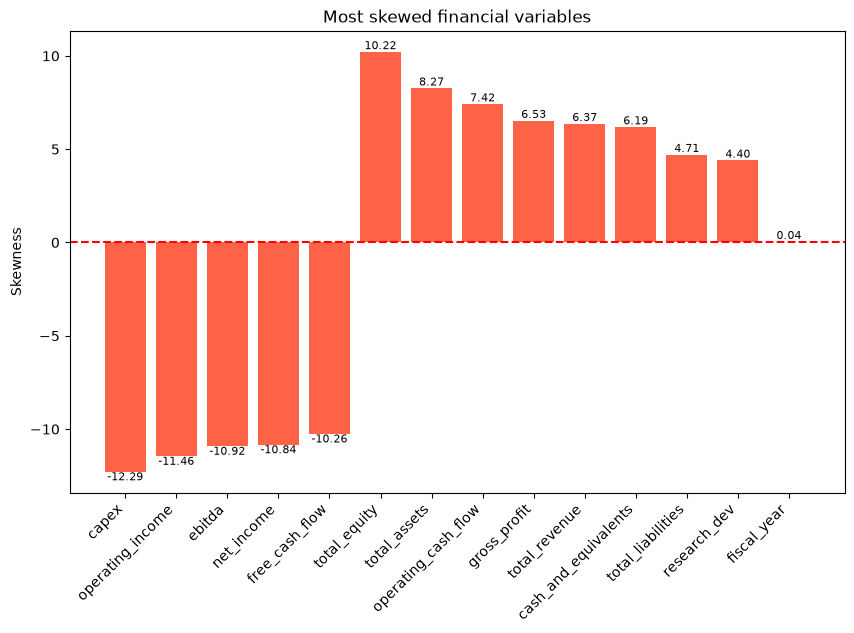

In [ ]:
skew_fin = (
    df_fin
    .select_dtypes(include=np.number)
    .skew()
    .sort_values(key=np.abs, ascending=False)
)

colors = [
    "tomato" if abs(v) > 1 else "steelblue"
    for v in skew_fin
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    range(len(skew_fin)),
    skew_fin.values,
    color=colors
)

plt.xticks(
    range(len(skew_fin)),
    skew_fin.index,
    rotation=45,
    ha="right"
)

for bar in bars:
    height = bar.get_height()

    plt.text( # добавляем текст для каждого бара
        bar.get_x() + bar.get_width()/2, #левая граница + половина ширины = получаем серидину бара
        height, 
        f"{height:.2f}",
        ha="center",
        va="bottom" if height > 0 else "top",
        fontsize=8
    )

plt.axhline(0, color="red", linestyle="--")

plt.title("Most skewed financial variables")
plt.ylabel("Skewness")
plt.show()

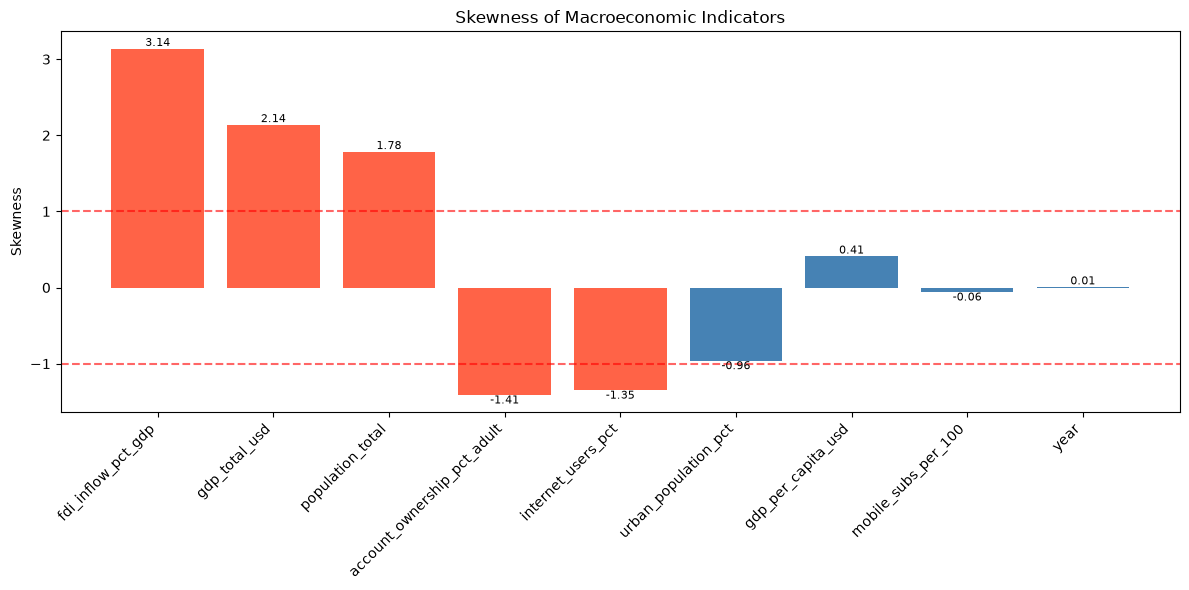

In [152]:

skew_macro = (
    macro_raw_wide
    .select_dtypes(include=np.number)
    .skew()
    .sort_values(key=np.abs, ascending=False)
)

colors = [
    "tomato" if abs(v) > 1 else "steelblue"
    for v in skew_macro
]

plt.figure(figsize=(12, 6))

bars = plt.bar(
    range(len(skew_macro)),
    skew_macro.values,
    color=colors
)

plt.xticks(
    range(len(skew_macro)),
    skew_macro.index,
    rotation=45,
    ha="right"
)

plt.axhline(1, color="red", linestyle="--", alpha=0.6)
plt.axhline(-1, color="red", linestyle="--", alpha=0.6)

plt.ylabel("Skewness")
plt.title("Skewness of Macroeconomic Indicators")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom" if height > 0 else "top",
        fontsize=8
    )

plt.tight_layout()
plt.show()

Several financial variables exhibit substantial skewness (|skew| > 1), particularly capex, free cash flow and net income. This behaviour is expected because the sample contains firms of vastly different sizes and profitability levels. Since many financial variables contain negative values, logarithmic transformation is not universally applicable and was therefore not used.

Log tranformation doesn't work well in financial data.:

* net_income can be negative;
* free_cash_flow can be negative;
* capex is almost always negative;
* operating_income can be negative.

That is, the logarithm for half of the financial indicators is simply not defined.

**Null processing**

In [153]:
df.isna().sum()

company_id                0
name                      0
ticker_x                  0
exchange                  0
reporting_currency        0
country_code_x            0
region_x                  0
segment_x                 0
wikipedia_title           0
wikidata_qid              0
wiki_title_canonical      2
founded_date              4
headquarters              5
founders                 16
industry                  8
employees                37
employees_year           37
website                   2
wiki_extract              2
wiki_url                  2
wiki_thumbnail           15
ticker_y                  0
country_code_y            0
region_y                  0
segment_y                 0
history_start             0
history_end               0
trading_days              0
first_close               0
last_close               13
cumulative_return        13
cagr                     13
annualized_volatility     0
max_drawdown              0
all_time_high             0
all_time_high_date  

* return_90d = profitability over the last 90 days
* return_1y = profitability for the last year

1. Since there are only 4 out of 43 passes for founded_date, the dates will be checked manually
2. to fill in last_close, we will look at the last price in stock performance
3. Statistically insignificant data with a large number of omissions such as headquarters, founders, employees, employees_year will be deleted

In [154]:
print(len(df['headquarters'].unique()))
print(len(df['founders'].unique()))

31
28


In [155]:
cum_ids = set(df.loc[df["cumulative_return"].isna(), "company_id"])
cagr_ids = set(df.loc[df["cagr"].isna(), "company_id"])
ret90_ids = set(df.loc[df["return_90d"].isna(), "company_id"])
ret1y_ids = set(df.loc[df["return_1y"].isna(), "company_id"])

print(cum_ids == cagr_ids == ret90_ids == ret1y_ids)

True


Conclusion: the companies with passes are the same

In [156]:
df.loc[
    df["cumulative_return"].isna(),
    ["company_id", "history_start", "history_end", "trading_days", "exchange"]
]

,company_id,history_start,history_end,trading_days,exchange
19,zalando,2015-01-02,2026-05-13,2886,Xetra
24,allegro,2020-10-13,2026-05-13,1395,WSE
27,nykaa,2021-11-10,2026-05-13,1114,NSE
29,paytm,2021-11-18,2026-05-13,1108,NSE
30,policybazaar,2021-11-15,2026-05-13,1110,NSE
31,indiamart,2019-07-04,2026-05-13,1696,NSE
32,infoedge,2015-01-01,2026-05-13,2805,NSE
33,cartrade,2021-08-20,2026-05-13,1169,NSE
34,easetrip,2021-03-19,2026-05-13,1272,NSE
35,honasa,2023-11-07,2026-05-13,619,NSE


Check the hypothesis formula

In [157]:
sample = df[df["cagr"].notna()].iloc[0].copy()
print(sample)

company_id                                                          amazon
name                                                            Amazon.com
ticker_x                                                              AMZN
exchange                                                            NASDAQ
reporting_currency                                                     USD
country_code_x                                                          US
region_x                                                     North America
segment_x                                              Marketplace + Cloud
wikipedia_title                                           Amazon (company)
wikidata_qid                                                         Q3884
wiki_title_canonical                                      Amazon (company)
founded_date                                                    1994-07-05
headquarters                                                       Seattle
founders                 

In [158]:
print("Cammulative comparison")
print((sample["last_close"] / sample["first_close"]) - 1)
print(sample["cumulative_return"])
print("CAGR comparison")

history_start = pd.to_datetime(sample["history_start"])
history_end = pd.to_datetime(sample["history_end"])

years = (history_end - history_start).days / 365.25

calc_cagr = (
    (sample["last_close"] / sample["first_close"])
    ** (1 / years)
    - 1
)

print(calc_cagr)
print(sample["cagr"])

Cammulative comparison
16.511345206927118
16.511345206927118
CAGR comparison
0.28662939981725577
0.2866293998172557


In [ ]:
company_id = sample["company_id"]

tmp = (
    df_stick[df_stick["company_id"] == company_id] #ВНИНАМИНЕ здесь смотрим последнюю дату по stock prices
    .sort_values("date")
    .copy()
)

tmp["date"] = pd.to_datetime(tmp["date"])

last_date = tmp.iloc[-1]["date"]
last_price = tmp.iloc[-1]["adj_close"]

# 90 календарных дней назад
target_90d = last_date - pd.DateOffset(days=128)

# последняя доступная торговая дата не позже target_90d
price_90d = tmp.loc[
    tmp["date"] <= target_90d,
    "adj_close"
].iloc[-1]

print("90d return:")
print((last_price / price_90d) - 1)
print(sample["return_90d"])

90d return:
0.15905778646075452
0.1590577864607545


In [295]:
target_price = last_price / (1 + sample["return_90d"])

closest = tmp.iloc[
    (tmp["adj_close"] - target_price).abs().argmin()
]

print(closest[["date", "adj_close"]])
days_diff = (last_date - closest["date"]).days

print("calendar days:", days_diff)

date         2026-01-05 00:00:00
adj_close             233.059998
Name: 8358, dtype: object
calendar days: 128


In [296]:
tmp = tmp.reset_index(drop=True)

closest_idx = (
    tmp["adj_close"] - target_price
).abs().argmin()

trading_days = len(tmp) - 1 - closest_idx

print(trading_days)

89


.argmin() - возвращает именно индекс мин знач

In [ ]:
target_1y = last_date - pd.DateOffset(years=1)

price_1y = tmp.loc[
    tmp["date"] <= target_1y,
    "adj_close"
].iloc[-1]

print("1y return:")
print((last_price / price_1y) - 1)
print(sample["return_1y"])

1y return:
0.2779959839287849
0.2779959839287849


-> restored all formulas

In [163]:
print(df_stick["company_id"].head())
print(df_stick["company_id"].dtype)

print(df["company_id"].head())
print(df["company_id"].dtype)

0    affirm
1    affirm
2    affirm
3    affirm
4    affirm
Name: company_id, dtype: str
str
0     amazon
1       ebay
2       etsy
3    shopify
4    wayfair
Name: company_id, dtype: str
str


In [95]:
df_comp = pd.read_csv('companies.csv')#done
df_metrics = pd.read_csv('company_metrics.csv')#done
df = df_comp.merge(
    df_metrics,
    on="company_id",
    how="inner"
)
df_stick = pd.read_csv('prices_daily.csv')

Finall ckeck across the whole data

In [ ]:
print("Cumulative return check")

mask = df["cumulative_return"].notna()

calc = (
    df.loc[mask, "last_close"] /
    df.loc[mask, "first_close"]
) - 1

comparison = pd.DataFrame({
    "actual": df.loc[mask, "cumulative_return"],
    "calculated": calc
})

comparison["diff"] = (
    comparison["actual"] -
    comparison["calculated"]
).abs().round(10)

print("max diff:", comparison["diff"].max())
print("mean diff:", comparison["diff"].mean())

print("CAGR check")

mask = df["cagr"].notna()

history_start = pd.to_datetime(df.loc[mask, "history_start"])
history_end = pd.to_datetime(df.loc[mask, "history_end"])

years = (
    (history_end - history_start).dt.days
) / 365.25

calc = (
    (
        df.loc[mask, "last_close"] /
        df.loc[mask, "first_close"]
    ) ** (1 / years)
) - 1

comparison = pd.DataFrame({
    "actual": df.loc[mask, "cagr"],
    "calculated": calc
})

comparison["diff"] = (
    comparison["actual"] -
    comparison["calculated"]
).abs().round(10)

print("max diff:", comparison["diff"].max())
print("mean diff:", comparison["diff"].mean())

print("Return 1Y check")

mask = df["return_1y"].notna()

calc_returns = []
i = 0
for idx in df.loc[mask].index:

    company_id = df.loc[idx, "company_id"]

    tmp = (
        df_stick[df_stick["company_id"] == company_id]
        .sort_values("date")
        .copy()
    )

    tmp["date"] = pd.to_datetime(tmp["date"])
    #=======================
    try:
      last_date = tmp.iloc[-1]["date"]
    except:
      print(tmp)
      print("iteration:", i)
      print("idx:", idx)
      print("company_id:", company_id)
      print(df.loc[idx])
      break
    last_price = tmp.iloc[-1]["adj_close"]
    i+=1

    target_date = last_date - pd.DateOffset(years=1)

    price_1y = tmp.loc[
        tmp["date"] <= target_date,
        "adj_close"
    ].iloc[-1]

    calc_returns.append(
        (last_price / price_1y) - 1
    )

comparison = pd.DataFrame({
    "actual": df.loc[mask, "return_1y"].values,
    "calculated": calc_returns
})

comparison["diff"] = (
    (comparison["actual"]) -
    (comparison["calculated"])
).abs().round(10)

print("max diff:", comparison["diff"].max())
print("mean diff:", comparison["diff"].mean())


print("Return 90D check")

mask = df["return_90d"].notna()

calc_returns = []

for idx in df.loc[mask].index: #тут для каждой компании надо сделать дополнительные рассчеты через stock prices а вот для cagr - все данные уже в одной строчке

    company_id = df.loc[idx, "company_id"]

    tmp = (
        df_stick[df_stick["company_id"] == company_id]
        .sort_values("date")
        .reset_index(drop=True)
    )
    tmp["date"] = pd.to_datetime(tmp["date"])
    last_date = tmp.iloc[-1]["date"]
    last_price = tmp.iloc[-1]["adj_close"]
    target_90d = last_date - pd.DateOffset(days=128)
    price_90d = tmp.loc[
    tmp["date"] <= target_90d,
    "adj_close"].iloc[-1]

    calc_returns.append(
        (last_price / price_90d) - 1
    )

comparison = pd.DataFrame({
    "actual": df.loc[mask, "return_90d"].values,
    "calculated": calc_returns
})

comparison["diff"] = (
    (comparison["actual"]) -
    (comparison["calculated"])
).abs().round(10)

print("max diff:", comparison["diff"].max())
print("mean diff:", comparison["diff"].mean())


Cumulative return check
max diff: 0.0
mean diff: 0.0
CAGR check
max diff: 0.0
mean diff: 0.0
Return 1Y check
max diff: 0.0629703856
mean diff: 0.006388379060000001
Return 90D check
max diff: 0.0339366516
mean diff: 0.00126103316


filling in the gaps according to the found formulas

In [165]:
df_filled = df.copy()

In [166]:
cols_to_drop = [
    "headquarters",
    "founders",
    "employees",
    "employees_year",
    "name",
    "reporting_currency",
    "wikipedia_title",
    "wikidata_qid",
    "wiki_title_canonical",
    "website",
    "wiki_extract",
    "wiki_url",
    "wiki_thumbnail"
]

df_filled = df_filled.drop(columns=cols_to_drop)

In [299]:
for idx in df_filled.index:

    if pd.notna(df_filled.loc[idx, "cumulative_return"]):
      continue

    #print(df_filled.loc[idx])
    company_id = df_filled.loc[idx, "company_id"]

    tmp = (
        df_stick[df_stick["company_id"] == company_id]
        .sort_values("date")
        .reset_index(drop=True)
    )

    tmp["date"] = pd.to_datetime(tmp["date"])
    tmp = tmp.sort_values("date").reset_index(drop=True)

    if len(tmp) == 0:
      continue

    first_price = tmp.iloc[0]["adj_close"]
    last_price = tmp.iloc[-2]["adj_close"]
    last_date = tmp.iloc[-2]["date"]
    #print(tmp)
    #print(last_price)


    # last_close
    df_filled.loc[idx, "last_close"] = last_price


    # cumulative return
    df_filled.loc[idx, "cumulative_return"] = (
        last_price / first_price
    ) - 1
    #print(df_filled.loc[idx, "cumulative_return"])


    # CAGR
    history_start = pd.to_datetime(df_filled.loc[idx, "history_start"])
    history_end = pd.to_datetime(df_filled.loc[idx, "history_end"])

    years = (history_end - history_start).days / 365.25

    if years > 0:
      df_filled.loc[idx, "cagr"] = (
          (last_price / first_price) ** (1 / years)
      ) - 1
    else:
      df_filled.loc[idx, "cagr"] = np.nan


    #for return close is calculated by adjusted close
    first_price = tmp.iloc[0]["adj_close"]
    last_price = tmp.iloc[-2]["adj_close"]

    # return_1y
    target_1y = last_date - pd.DateOffset(years=1)

    subset_1y = tmp.loc[
      tmp["date"] <= target_1y,
      "adj_close"
    ]

    if len(subset_1y) > 0:
      price_1y = subset_1y.iloc[-1]

      df_filled.loc[idx, "return_1y"] = (
          last_price / price_1y
      ) - 1
    else:
      df_filled.loc[idx, "return_1y"] = np.nan


    # return_90d
    target_90d = last_date - pd.DateOffset(days=128)

    subset_90d = tmp.loc[
      tmp["date"] <= target_90d,
      "adj_close"
    ]

    if len(subset_90d) > 0:
      price_90d = subset_90d.iloc[-1]

      df_filled.loc[idx, "return_90d"] = (
          last_price / price_90d
      ) - 1
    else:
      df_filled.loc[idx, "return_90d"] = np.nan

print(df_filled.isna().sum())

company_id               0
ticker_x                 0
exchange                 0
country_code_x           0
region_x                 0
segment_x                0
founded_date             0
industry                 8
ticker_y                 0
country_code_y           0
region_y                 0
segment_y                0
history_start            0
history_end              0
trading_days             0
first_close              0
last_close               0
cumulative_return        0
cagr                     0
annualized_volatility    0
max_drawdown             0
all_time_high            0
all_time_high_date       0
return_90d               0
return_1y                0
latest_fiscal_year       0
total_revenue            0
net_income               0
operating_income         0
total_assets             0
free_cash_flow           0
net_margin               0
operating_margin         0
revenue_cagr             0
revenue_cagr_years       0
dtype: int64


In [298]:
df_filled.dtypes

company_id                          str
ticker_x                            str
exchange                            str
country_code_x                      str
region_x                            str
segment_x                           str
founded_date             datetime64[us]
industry                            str
ticker_y                            str
country_code_y                      str
region_y                            str
segment_y                           str
history_start                       str
history_end                         str
trading_days                      int64
first_close                     float64
last_close                      float64
cumulative_return               float64
cagr                            float64
annualized_volatility           float64
max_drawdown                    float64
all_time_high                   float64
all_time_high_date                  str
return_90d                      float64
return_1y                       float64


In [100]:
df_filled.loc[df_filled["founded_date"].isna()]

,company_id,ticker_x,exchange,country_code_x,region_x,segment_x,founded_date,industry,ticker_y,country_code_y,...,latest_fiscal_year,total_revenue,net_income,operating_income,total_assets,free_cash_flow,net_margin,operating_margin,revenue_cagr,revenue_cagr_years
6,carvana,CVNA,NYSE,US,North America,Used Cars,NaN,e-commerce,CVNA,US,...,2025,2.032200e+10,1.407000e+09,1.881000e+09,1.320100e+10,8.890000e+08,0.069235,0.092560,0.143141,3
16,sea,SE,NYSE,SG,Asia Pacific,Marketplace + Gaming,NaN,e-commerce,SE,SG,...,2025,2.293847e+10,1.578149e+09,1.985306e+09,2.937098e+10,4.500024e+09,0.068799,0.086549,0.225938,3
36,delhivery,DELHIVERY.NS,NSE,IN,India,E-commerce Logistics,NaN,logistics,DELHIVERY.NS,IN,...,2025,8.931901e+10,1.621100e+09,-1.551020e+09,1.206314e+11,8.418200e+08,0.018150,-0.017365,0.090780,3
41,affirm,AFRM,NASDAQ,US,North America,BNPL,NaN,NaN,AFRM,US,...,2025,3.224412e+09,5.218600e+07,3.379930e+08,1.115493e+10,6.017200e+08,0.016185,0.104823,0.336949,3


Were founded in the open sources manually since the number of missed values is small

carvana - 04.01.2012

sea - 08.05.2009

delhivery - 01.05.2011

affirm - 17.01.2012


In [168]:
df_filled.loc[
    df_filled["founded_date"].str.contains("-00", na=False),
    ["company_id", "founded_date"]
]

,company_id,founded_date
3,shopify,2006-00-00
4,wayfair,2002-00-00
8,stitchfix,2011-00-00
9,instacart,2012-00-00
10,doordash,2012-00-00
12,jdcom,2004-00-00
13,pinduoduo,2015-09-00
14,vipshop,2008-12-00
19,zalando,2008-00-00
21,boohoo,2006-00-00


In [ ]:
df_filled.loc[
    df_filled["company_id"] == "carvana",
    "founded_date"
] = "2012-01-04"

df_filled.loc[
    df_filled["company_id"] == "sea",
    "founded_date"
] = "2009-05-08"

df_filled.loc[
    df_filled["company_id"] == "delhivery",
    "founded_date"
] = "2011-05-01"

df_filled.loc[
    df_filled["company_id"] == "affirm",
    "founded_date"
] = "2012-01-17"

df_filled["founded_date"] = (
    df_filled["founded_date"]
    .str.replace("-00-", "-01-", regex=False)
    .str.replace(r"-00$", "-01", regex=True)
) #чтобы все нормально преобразовалось в дату

df_filled["founded_date"] = pd.to_datetime(df_filled["founded_date"])

In [102]:
df_filled.head(10)

,company_id,ticker_x,exchange,country_code_x,region_x,segment_x,founded_date,industry,ticker_y,country_code_y,...,latest_fiscal_year,total_revenue,net_income,operating_income,total_assets,free_cash_flow,net_margin,operating_margin,revenue_cagr,revenue_cagr_years
0,amazon,AMZN,NASDAQ,US,North America,Marketplace + Cloud,1994-07-05,retail,AMZN,US,...,2025,7.169240e+11,7.767000e+10,7.997500e+10,8.180420e+11,7.695000e+09,0.108338,0.111553,0.117313,3
1,ebay,EBAY,NASDAQ,US,North America,C2C Marketplace,1995-09-03,e-commerce,EBAY,US,...,2025,1.110000e+10,2.031000e+09,2.277000e+09,1.761000e+10,1.434000e+09,0.182973,0.205135,0.042572,3
2,etsy,ETSY,NASDAQ,US,North America,Handmade Marketplace,2005-06-18,e-commerce,ETSY,US,...,2025,2.883501e+09,1.629820e+08,3.679130e+08,2.827254e+09,6.387500e+08,0.056522,0.127592,0.039637,3
3,shopify,SHOP,NYSE,CA,North America,E-commerce SaaS,2006-01-01,e-commerce,SHOP,CA,...,2025,1.155600e+10,1.231000e+09,1.885000e+09,1.518900e+10,2.007000e+09,0.106525,0.163119,0.273131,3
4,wayfair,W,NYSE,US,North America,Home Goods,2002-01-01,e-commerce,W,US,...,2025,1.245700e+10,-3.130000e+08,9.300000e+07,3.440000e+09,3.290000e+08,-0.025126,0.007466,0.006478,3
5,chewy,CHWY,NYSE,US,North America,Pet Supplies,2011-01-01,retail,CHWY,US,...,2026,1.260150e+10,2.228000e+08,2.543000e+08,3.366400e+09,5.624000e+08,0.017680,0.020180,0.075874,3
6,carvana,CVNA,NYSE,US,North America,Used Cars,2012-01-04,e-commerce,CVNA,US,...,2025,2.032200e+10,1.407000e+09,1.881000e+09,1.320100e+10,8.890000e+08,0.069235,0.092560,0.143141,3
7,revolve,RVLV,NYSE,US,North America,Fashion,2003-01-01,Fashion retail,RVLV,US,...,2025,1.225682e+09,6.170900e+07,7.426300e+07,7.650010e+08,4.799100e+07,0.050347,0.060589,0.036276,3
8,stitchfix,SFIX,NASDAQ,US,North America,Personal Styling,2011-01-01,retail,SFIX,US,...,2025,1.267171e+09,-2.873900e+07,-3.890500e+07,4.806220e+08,9.282000e+06,-0.022680,-0.030702,-0.143648,3
9,instacart,CART,NASDAQ,US,North America,Grocery Delivery,2012-01-01,retail,CART,US,...,2025,3.742000e+09,4.470000e+08,4.980000e+08,3.687000e+09,9.100000e+08,0.119455,0.133084,0.136225,3


In [31]:
df.loc[df['industry'].isna(), 'company_id']

,company_id
13,pinduoduo
23,autotrader
24,allegro
28,zomato
31,indiamart
37,ixigo
39,paypal
41,affirm


In [170]:
df_filled['industry'].unique()

<ArrowStringArray>
[                'retail',             'e-commerce',         'Fashion retail',
  'food delivery service',                      nan,      'Internet industry',
 'information technology',      'clothing industry',             'mail order',
        'online shopping',   'economics of banking',     'insurance industry',
               'Internet',    'automotive industry',          'travel agency',
          'Personal care',              'logistics',     'financial services',
   'Financial technology']
Length: 19, dtype: str

In [33]:
df_ecommerce.head(5)

,date,constituents,daily_return,index_level
0,2015-01-05,13,NaN,99.953267
1,2015-01-06,14,-0.022106,97.743667
2,2015-01-07,14,-0.046385,93.209870
3,2015-01-08,14,0.016463,94.744410
4,2015-01-09,14,-0.010356,93.763193


In [34]:
df_ecommerce.isna().sum() #соответственно для первой даты только отсутствуюют значения

,0
date,0
constituents,0
daily_return,1
index_level,0


Most likely, prices were not affordable for all companies at the beginning of the story.

--------------------

--------------------

--------------------

--------------------

In [35]:
df_fin.head()

,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,total_liabilities,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow
0,affirm,AFRM,2022,1.349292e+09,7.728350e+08,-7.963540e+08,-7.074170e+08,-6.024150e+08,NaN,6.973792e+09,4.355537e+09,1.255171e+09,2.618255e+09,-1.621940e+08,-1.117050e+08,-2.738990e+08
1,affirm,AFRM,2023,1.587985e+09,7.148240e+08,-9.819790e+08,-9.853450e+08,-6.715980e+08,NaN,8.155615e+09,5.621432e+09,8.920270e+08,2.534183e+09,1.218100e+07,-1.207750e+08,-1.085940e+08
2,affirm,AFRM,2024,2.322999e+09,1.477893e+09,-2.648260e+08,-5.177570e+08,-2.230000e+06,NaN,9.519619e+09,6.787630e+09,1.013106e+09,2.731989e+09,4.501380e+08,-1.592960e+08,2.908420e+08
3,affirm,AFRM,2025,3.224412e+09,2.176840e+09,3.379930e+08,5.218600e+07,7.119910e+08,NaN,1.115493e+10,8.085920e+09,1.354455e+09,3.069009e+09,7.939090e+08,-1.921890e+08,6.017200e+08
4,alibaba,BABA,2022,8.530620e+11,3.136120e+11,9.477900e+10,6.224900e+10,1.282260e+11,5.546500e+10,1.695553e+12,6.133600e+11,1.898980e+11,9.484790e+11,1.427590e+11,-5.332400e+10,8.943500e+10


In [36]:
df_fin.shape

(175, 16)

In [171]:
df_fin.isna().sum()

company_id                0
ticker                    0
fiscal_year               0
total_revenue             3
gross_profit             12
operating_income          3
net_income                3
ebitda                    3
research_dev            114
total_assets              3
total_liabilities         3
cash_and_equivalents      3
total_equity              3
operating_cash_flow       7
capex                     3
free_cash_flow            3
dtype: int64

In [38]:
df.loc[df["company_id"] == "amazon", "history_start"]

,history_start
0,2015-01-02


In [39]:
df_fin[df_fin["company_id"] == "amazon"]

,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,total_liabilities,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow
12,amazon,AMZN,2022,5.139830e+11,2.251520e+11,1.224800e+10,-2.722000e+09,3.835200e+10,NaN,4.626750e+11,3.166320e+11,5.388800e+10,1.460430e+11,4.675200e+10,-6.364500e+10,-1.689300e+10
13,amazon,AMZN,2023,5.747850e+11,2.700460e+11,3.685200e+10,3.042500e+10,8.940200e+10,NaN,5.278540e+11,3.259790e+11,7.338700e+10,2.018750e+11,8.494600e+10,-5.272900e+10,3.221700e+10
14,amazon,AMZN,2024,6.379590e+11,3.116710e+11,6.859300e+10,5.924800e+10,1.238150e+11,NaN,6.248940e+11,3.389240e+11,7.877900e+10,2.859700e+11,1.158770e+11,-8.299900e+10,3.287800e+10
15,amazon,AMZN,2025,7.169240e+11,3.605100e+11,7.997500e+10,7.767000e+10,1.653410e+11,NaN,8.180420e+11,4.069770e+11,8.681000e+10,4.110650e+11,1.395140e+11,-1.318190e+11,7.695000e+09


Note that the beginning of market participation does not coincide with the beginning of the fiscal year -> well, that is, we will be able to take this data into account only at the end of the period, and before that we will have to look purely at ecommerce and macro factors.

net_income operating_income total_revenue ebitda total_assets total_liabilities cash_and_equivalents total_equity capex free_cash_flow

In [172]:
critical_cols = [
    "net_income",
    "operating_income",
    "total_revenue",
    "ebitda",
    "total_assets",
    "total_liabilities",
    "cash_and_equivalents",
    "total_equity",
    "capex",
    "free_cash_flow"
]

mask = df_fin[critical_cols].isna().all(axis=1)

df_fin[mask]

,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,total_liabilities,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow
36,cartrade,CARTRADE.NS,2022,NaN,3.022778e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85,indiamart,INDIAMART.NS,2022,NaN,6.928350e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,ocado,OCDO.L,2021,NaN,9.328000e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------

display(...) показывает отфильтрованный DataFrame в виде удобной HTML-таблицы

In [173]:
for company in [
    "cartrade",
    "indiamart",
    "ocado"
]:
    print(company)

    display(
        df_fin[
            df_fin["company_id"] == company
        ]
    )

cartrade


,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,total_liabilities,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow
36,cartrade,CARTRADE.NS,2022,NaN,3.022778e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,cartrade,CARTRADE.NS,2023,3.633028e+09,3.560732e+09,1.023380e+08,3.399760e+08,9.697680e+08,NaN,2.343228e+10,2.208260e+09,261132000.0,2.043446e+10,4.821610e+08,-71107000.0,4.110540e+08
38,cartrade,CARTRADE.NS,2024,4.895978e+09,4.890844e+09,4.427190e+08,1.430290e+08,1.462913e+09,NaN,2.509783e+10,3.529011e+09,221401000.0,2.069995e+10,1.587260e+08,-29103000.0,1.296230e+08
39,cartrade,CARTRADE.NS,2025,6.414573e+09,6.400059e+09,1.100088e+09,1.346508e+09,2.207487e+09,NaN,2.705239e+10,3.787379e+09,287629000.0,2.220621e+10,1.710230e+09,-53893000.0,1.656337e+09
40,cartrade,CARTRADE.NS,2026,7.792672e+09,NaN,2.183126e+09,2.229995e+09,3.409931e+09,NaN,3.009196e+10,3.907626e+09,314012000.0,2.483386e+10,2.569891e+09,-266122000.0,2.303769e+09


indiamart


,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,total_liabilities,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow
85,indiamart,INDIAMART.NS,2022,NaN,6.928350e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86,indiamart,INDIAMART.NS,2023,9.853990e+09,8.962730e+09,2.372850e+09,2.838270e+09,4.105040e+09,NaN,3.444630e+10,1.386138e+10,581060000.0,2.058492e+10,4.758280e+09,-172030000.0,4.586250e+09
87,indiamart,INDIAMART.NS,2024,1.196775e+10,1.102175e+10,2.950520e+09,3.339530e+09,4.997510e+09,NaN,3.448603e+10,1.712489e+10,848040000.0,1.736114e+10,5.591660e+09,-146770000.0,5.444890e+09
88,indiamart,INDIAMART.NS,2025,1.388400e+10,1.299274e+10,4.899000e+09,5.507000e+09,7.461000e+09,NaN,4.133685e+10,1.948395e+10,734840000.0,2.185290e+10,6.232000e+09,-79000000.0,6.153000e+09
89,indiamart,INDIAMART.NS,2026,1.569000e+10,NaN,5.016000e+09,4.747000e+09,6.793000e+09,NaN,4.624600e+10,2.224200e+10,804000000.0,2.400400e+10,6.942000e+09,-70000000.0,6.872000e+09


ocado


,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,total_liabilities,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow
114,ocado,OCDO.L,2021,NaN,932800000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,ocado,OCDO.L,2022,2.516800e+09,964300000.0,-525000000.0,-455500000.0,-62200000.0,NaN,4.813200e+09,2.878900e+09,1.303200e+09,1.837900e+09,7900000.0,-785900000.0,-778000000.0
116,ocado,OCDO.L,2023,1.122100e+09,NaN,-401800000.0,-314000000.0,252100000.0,NaN,4.429000e+09,2.918000e+09,8.827000e+08,1.487400e+09,82200000.0,-536400000.0,-454200000.0
117,ocado,OCDO.L,2024,1.214600e+09,NaN,-302100000.0,-336200000.0,219400000.0,NaN,4.156500e+09,2.985300e+09,7.305000e+08,1.185700e+09,268900000.0,-399400000.0,-130500000.0
118,ocado,OCDO.L,2025,1.381700e+09,NaN,-213200000.0,405200000.0,136300000.0,NaN,4.279000e+09,2.717700e+09,7.381000e+08,1.561300e+09,341700000.0,-378300000.0,-36600000.0


ну короче да, тупо первый год - нет данных

In [174]:
df_fin = df_fin.loc[~mask].copy()

-----------------

In [175]:
df_fin.loc[df_fin["gross_profit"].isna()]

,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,total_liabilities,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow
27,autotrader,AUTO.L,2025,6.011000e+08,NaN,3.732000e+08,2.826000e+08,3.979000e+08,NaN,6.396000e+08,7.020000e+07,1.530000e+07,5.694000e+08,3.046000e+08,-4.000000e+06,3.006000e+08
40,cartrade,CARTRADE.NS,2026,7.792672e+09,NaN,2.183126e+09,2.229995e+09,3.409931e+09,NaN,3.009196e+10,3.907626e+09,3.140120e+08,2.483386e+10,2.569891e+09,-2.661220e+08,2.303769e+09
89,indiamart,INDIAMART.NS,2026,1.569000e+10,NaN,5.016000e+09,4.747000e+09,6.793000e+09,NaN,4.624600e+10,2.224200e+10,8.040000e+08,2.400400e+10,6.942000e+09,-7.000000e+07,6.872000e+09
98,ixigo,IXIGO.NS,2022,3.795800e+09,NaN,-1.994200e+08,-2.438200e+08,-6.954000e+07,NaN,5.384710e+09,1.957850e+09,2.473300e+08,3.426860e+09,-3.434900e+08,-1.930000e+07,-3.627900e+08
99,ixigo,IXIGO.NS,2023,5.012500e+09,NaN,2.254200e+08,2.163800e+08,3.243800e+08,NaN,5.859250e+09,1.988060e+09,7.312500e+08,3.737640e+09,3.070200e+08,-5.458000e+07,2.524400e+08
116,ocado,OCDO.L,2023,1.122100e+09,NaN,-4.018000e+08,-3.140000e+08,2.521000e+08,NaN,4.429000e+09,2.918000e+09,8.827000e+08,1.487400e+09,8.220000e+07,-5.364000e+08,-4.542000e+08
117,ocado,OCDO.L,2024,1.214600e+09,NaN,-3.021000e+08,-3.362000e+08,2.194000e+08,NaN,4.156500e+09,2.985300e+09,7.305000e+08,1.185700e+09,2.689000e+08,-3.994000e+08,-1.305000e+08
118,ocado,OCDO.L,2025,1.381700e+09,NaN,-2.132000e+08,4.052000e+08,1.363000e+08,NaN,4.279000e+09,2.717700e+09,7.381000e+08,1.561300e+09,3.417000e+08,-3.783000e+08,-3.660000e+07
135,rakuten,4755.T,2022,1.920894e+12,NaN,-3.716120e+11,-3.772170e+11,1.179000e+09,NaN,2.040228e+13,1.955357e+13,4.694360e+12,7.913510e+11,-2.620680e+11,-4.352180e+11,-6.972860e+11
136,rakuten,4755.T,2023,2.071315e+12,NaN,-2.128570e+11,-3.394730e+11,1.466000e+11,NaN,2.262558e+13,2.153785e+13,5.127674e+12,8.365720e+11,7.241920e+11,-3.511570e+11,3.730350e+11


In [176]:
bebe = (
    df_fin[df_fin["gross_profit"].isna()][["company_id", "ticker", "fiscal_year"]]
    .merge(
        df_comp[["company_id", "industry"]],
        on="company_id",
        how="left"
    )
)

bebe

,company_id,ticker,fiscal_year,industry
0,autotrader,AUTO.L,2025,NaN
1,cartrade,CARTRADE.NS,2026,automotive industry
2,indiamart,INDIAMART.NS,2026,NaN
3,ixigo,IXIGO.NS,2022,NaN
4,ixigo,IXIGO.NS,2023,NaN
5,ocado,OCDO.L,2023,online shopping
6,ocado,OCDO.L,2024,online shopping
7,ocado,OCDO.L,2025,online shopping
8,rakuten,4755.T,2022,Internet industry
9,rakuten,4755.T,2023,Internet industry


These are either financial/marketplace companies, or companies where revenue = gross_profit is by nature a business. - gross_profit is missing from marketplace/financial type companies where this metric is not standard. The analysis uses operating_margin as a universal analog.

In [177]:
df_fin["operating_margin"] = df_fin["operating_income"] / df_fin["total_revenue"]

------------------------

---------------------------------------

------------------------------

-----------------------------------

-----------------------------------

In [178]:
df_fin.columns

Index(['company_id', 'ticker', 'fiscal_year', 'total_revenue', 'gross_profit',
       'operating_income', 'net_income', 'ebitda', 'research_dev',
       'total_assets', 'total_liabilities', 'cash_and_equivalents',
       'total_equity', 'operating_cash_flow', 'capex', 'free_cash_flow',
       'operating_margin'],
      dtype='str')

In [179]:
df_fin['research_dev'].head(10)

0             NaN
1             NaN
2             NaN
3             NaN
4    5.546500e+10
5    5.674400e+10
6    5.225600e+10
7    5.715100e+10
8             NaN
9             NaN
Name: research_dev, dtype: float64

In [180]:
df_fin.groupby("company_id")["fiscal_year"].min()

company_id
affirm          2022
alibaba         2022
allegro         2022
amazon          2022
ao              2022
asos            2022
autotrader      2022
block           2022
boohoo          2022
cartrade        2023
carvana         2022
chewy           2023
coupang         2022
delhivery       2022
doordash        2022
easetrip        2022
ebay            2022
etsy            2022
firstcry        2022
gotogroup       2022
honasa          2022
indiamart       2023
infoedge        2022
instacart       2022
ixigo           2022
jdcom           2022
mercadolibre    2022
nykaa           2022
ocado           2022
paypal          2022
paytm           2023
pinduoduo       2022
policybazaar    2023
rakuten         2022
revolve         2022
sea             2022
shopify         2022
stitchfix       2022
stoneco         2022
vipshop         2022
wayfair         2022
zalando         2022
zomato          2023
Name: fiscal_year, dtype: int64

* скорее всего расходы на research_dev присутствуют только у крупных компаний, или же по секторам
* вообще по хорошему надо определить индикатор, что компания крупная -> возможно только тогда research_dev будет как то влиять на market perfomance, возможно то же самое для ocf

In [181]:
df_fin_full = df_fin.merge(
    df[
        ["company_id", "segment_x", "country_code_x"]
    ],
    on="company_id",
    how="left"
)

In [182]:
df_fin_full["has_rd"] = df_fin_full["research_dev"].notna()

In [183]:
df_fin_full["has_rd"] = (
    df_fin_full["research_dev"]
    .notna()
    .astype(int)
)

corr = df_fin_full[
    [
        "has_rd",
        "total_revenue",
        "total_assets",
        "net_income",
        "ebitda"
    ]
].corr()
print(corr)

                 has_rd  total_revenue  total_assets  net_income    ebitda
has_rd         1.000000       0.212714      0.146061   -0.141459 -0.139431
total_revenue  0.212714       1.000000      0.776590   -0.610339 -0.594712
total_assets   0.146061       0.776590      1.000000   -0.633487 -0.619134
net_income    -0.141459      -0.610339     -0.633487    1.000000  0.999765
ebitda        -0.139431      -0.594712     -0.619134    0.999765  1.000000


In [71]:
df_fin_full.columns

Index(['company_id', 'ticker', 'fiscal_year', 'total_revenue', 'gross_profit',
       'operating_income', 'net_income', 'ebitda', 'research_dev',
       'total_assets', 'total_liabilities', 'cash_and_equivalents',
       'total_equity', 'operating_cash_flow', 'capex', 'free_cash_flow',
       'segment_x', 'country_code_x', 'has_rd'],
      dtype='str')

In [184]:
corr = df_fin_full[
    [
        "has_rd",
        "total_revenue",
        "total_assets",
        "net_income",
        "ebitda",
        "operating_income",
        "total_liabilities",
        "cash_and_equivalents",
        "operating_cash_flow",
        "capex",
        "free_cash_flow",
        "total_equity"
    ]
].corr()
print(corr['has_rd'])

has_rd                  1.000000
total_revenue           0.212714
total_assets            0.146061
net_income             -0.141459
ebitda                 -0.139431
operating_income       -0.135839
total_liabilities       0.031173
cash_and_equivalents    0.178754
operating_cash_flow     0.001852
capex                  -0.120493
free_cash_flow         -0.156357
total_equity            0.172309
Name: has_rd, dtype: float64


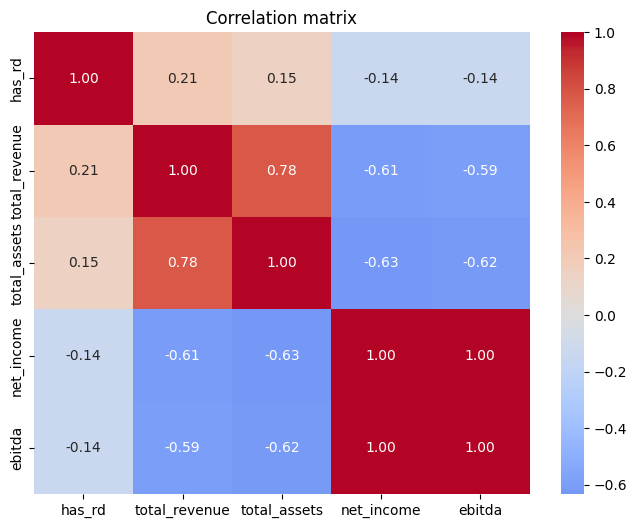

In [53]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation matrix")
plt.show()

In [ ]:
df_fin_full["rd_intensity"] = df_fin["research_dev"] / df_fin["total_revenue"]

In [ ]:
df_fin_full["has_rd"] = df_fin["research_dev"].notna().astype(int)

In [ ]:
segment_map = df_filled.set_index("company_id")["segment_x"].to_dict() #сначала превращаем в series потом в словарь

In [ ]:
df_fin_full.groupby(df_fin["company_id"].map(segment_map))["has_rd"].agg( #Для каждого company_id из df_fin словарь ищет соответствующий сегмент
    ["sum", "count", "mean"] #agg их сам считает
).rename(columns={"mean": "rd_presence_rate"})

,sum,count,rd_presence_rate
company_id,,,
1P + 3P Retail,4,4,1.000000
1P Retail,1,4,0.250000
Appliances,1,4,0.250000
Auto Classifieds,0,8,0.000000
B2B Marketplace,0,4,0.000000
BNPL,0,4,0.000000
Baby & Kids,1,4,0.250000
Beauty,0,4,0.000000
C2C Marketplace,4,4,1.000000


In [ ]:
df_fin.groupby("has_rd")["total_revenue"].describe(
    percentiles=[.25, .5, .75]
)

,count,mean,std,min,25%,50%,75%,max
has_rd,,,,,,,,
0,111.0,1.278955e+11,4.219545e+11,4.327000e+08,2.711300e+09,1.145820e+10,4.366080e+10,2.496575e+12
1,61.0,1.158675e+12,3.792532e+12,1.368300e+09,9.795000e+09,2.066949e+10,1.305576e+11,1.832212e+13


--------------------

----------------------

----------------------------

исследуем operating_cash_flow

In [191]:
df_fin_full.loc[df_fin_full['operating_cash_flow'].isna()]

,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,...,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow,operating_margin,segment_x,country_code_x,has_rd,rd_intensity
76,gotogroup,GOTO.JK,2022,1.134917e+13,5.869197e+12,-3.032963e+13,-3.957116e+13,-3.743840e+13,4.642199e+12,1.392166e+14,...,2.900918e+13,1.249211e+14,NaN,-4.521360e+11,-1.765844e+13,-2.672410,Super-app,ID,1,NaN
77,gotogroup,GOTO.JK,2023,1.478549e+13,9.692313e+12,-1.027897e+13,-9.039563e+13,-8.760549e+13,3.517369e+12,5.409726e+13,...,2.514394e+13,3.793026e+13,NaN,-2.204470e+11,-4.545755e+12,-0.695206,Super-app,ID,1,0.409034
78,gotogroup,GOTO.JK,2024,1.589446e+13,8.481070e+12,-2.240874e+12,-5.154924e+12,-4.047292e+12,1.756068e+12,4.320788e+13,...,1.917752e+13,3.298924e+13,NaN,-6.518862e+12,-7.140976e+12,-0.140985,Super-app,ID,1,0.237893
79,gotogroup,GOTO.JK,2025,1.832212e+13,1.057608e+13,-3.782540e+11,-1.185654e+12,1.846640e+11,2.152272e+12,4.575764e+13,...,2.175516e+13,3.180502e+13,NaN,-1.182360e+12,-8.753350e+11,-0.020645,Super-app,ID,1,0.110483


GoTo (GOTO.JK) — индонезийская компания, отчитывается по местным стандартам. Скорее всего данные просто не были доступны в источнике. При этом у них есть capex и free_cash_flow — это странно, потому что FCF = OCF - capex. Значит либо источник вернул FCF напрямую, либо ошибка в данных.

In [192]:
goto_mask = df_fin_full["ticker"] == "GOTO.JK"

может у них просто тогда capex указывается сразу в отрицательном значении и оно как раз и прибавляется к ocf? - проблема что и capex и fco отриц

In [194]:
# Если FCF и capex есть — можно восстановить OCF
# OCF = FCF + capex (capex обычно отрицательный)
print(df_fin_full.loc[goto_mask, "operating_cash_flow"] == (
    df_fin_full.loc[goto_mask, "free_cash_flow"] +
    df_fin_full.loc[goto_mask, "capex"].abs()
))

76    False
77    False
78    False
79    False
dtype: bool


проверим формулу

In [195]:
# Проверяем формулу на компаниях где OCF не NaN
df_check = df_fin_full[df_fin_full["operating_cash_flow"].notna()].copy()

df_check["ocf_reconstructed"] = df_check["free_cash_flow"] - df_check["capex"]
df_check["ocf_diff"] = df_check["ocf_reconstructed"] - df_check["operating_cash_flow"]
df_check["ocf_diff_pct"] = df_check["ocf_diff"] / df_check["operating_cash_flow"].abs() * 100

# Смотрим результат
df_check[["ticker", "fiscal_year", "operating_cash_flow",
          "ocf_reconstructed", "ocf_diff_pct"]].sort_values("ocf_diff_pct", key=abs).head(20)

,ticker,fiscal_year,operating_cash_flow,ocf_reconstructed,ocf_diff_pct
0,AFRM,2022,-1.621940e+08,-1.621940e+08,0.0
1,AFRM,2023,1.218100e+07,1.218100e+07,0.0
2,AFRM,2024,4.501380e+08,4.501380e+08,0.0
3,AFRM,2025,7.939090e+08,7.939090e+08,0.0
4,BABA,2022,1.427590e+11,1.427590e+11,0.0
5,BABA,2023,1.997520e+11,1.997520e+11,0.0
6,BABA,2024,1.825930e+11,1.825930e+11,0.0
7,BABA,2025,1.635090e+11,1.635090e+11,0.0
8,ALE.WA,2022,1.854680e+09,1.854680e+09,0.0
9,ALE.WA,2023,2.540857e+09,2.540857e+09,0.0


In [196]:
df_fin_full.loc[goto_mask, "operating_cash_flow"] = (
    df_fin_full.loc[goto_mask, "free_cash_flow"] -
    df_fin_full.loc[goto_mask, "capex"]
)

# Проверка
df_fin_full.loc[goto_mask, ["fiscal_year", "operating_cash_flow", "free_cash_flow", "capex"]]

,fiscal_year,operating_cash_flow,free_cash_flow,capex
76,2022,-1.720630e+13,-1.765844e+13,-4.521360e+11
77,2023,-4.325308e+12,-4.545755e+12,-2.204470e+11
78,2024,-6.221140e+11,-7.140976e+12,-6.518862e+12
79,2025,3.070250e+11,-8.753350e+11,-1.182360e+12


In [197]:
df_fin_full.head()

,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,...,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow,operating_margin,segment_x,country_code_x,has_rd,rd_intensity
0,affirm,AFRM,2022,1.349292e+09,7.728350e+08,-7.963540e+08,-7.074170e+08,-6.024150e+08,NaN,6.973792e+09,...,1.255171e+09,2.618255e+09,-1.621940e+08,-1.117050e+08,-2.738990e+08,-0.590201,BNPL,US,0,NaN
1,affirm,AFRM,2023,1.587985e+09,7.148240e+08,-9.819790e+08,-9.853450e+08,-6.715980e+08,NaN,8.155615e+09,...,8.920270e+08,2.534183e+09,1.218100e+07,-1.207750e+08,-1.085940e+08,-0.618381,BNPL,US,0,NaN
2,affirm,AFRM,2024,2.322999e+09,1.477893e+09,-2.648260e+08,-5.177570e+08,-2.230000e+06,NaN,9.519619e+09,...,1.013106e+09,2.731989e+09,4.501380e+08,-1.592960e+08,2.908420e+08,-0.114002,BNPL,US,0,NaN
3,affirm,AFRM,2025,3.224412e+09,2.176840e+09,3.379930e+08,5.218600e+07,7.119910e+08,NaN,1.115493e+10,...,1.354455e+09,3.069009e+09,7.939090e+08,-1.921890e+08,6.017200e+08,0.104823,BNPL,US,0,NaN
4,alibaba,BABA,2022,8.530620e+11,3.136120e+11,9.477900e+10,6.224900e+10,1.282260e+11,5.546500e+10,1.695553e+12,...,1.898980e+11,9.484790e+11,1.427590e+11,-5.332400e+10,8.943500e+10,0.111104,Marketplace + Cloud,CN,1,0.065019


----------------------

-------------------

 ----------------------------------

-------------------------------

In [65]:
df_macro.head()

,country_code,year,indicator_id,indicator_name,value
0,AR,2011,FX.OWN.TOTL.ZS,account_ownership_pct_adult,33.130217
1,AR,2014,FX.OWN.TOTL.ZS,account_ownership_pct_adult,50.197294
2,AR,2017,FX.OWN.TOTL.ZS,account_ownership_pct_adult,48.708487
3,AR,2021,FX.OWN.TOTL.ZS,account_ownership_pct_adult,71.627086
4,AR,2024,FX.OWN.TOTL.ZS,account_ownership_pct_adult,81.744245


In [66]:
df_macro["indicator_name"].value_counts()

,count
indicator_name,
internet_users_pct,197
fdi_inflow_pct_gdp,195
gdp_per_capita_usd,195
population_total,195
urban_population_pct,195
mobile_subs_per_100,194
gdp_total_usd,180
account_ownership_pct_adult,65


In [67]:
df_macro.isna().sum()

,0
country_code,0
year,0
indicator_id,0
indicator_name,0
value,0


In [116]:
for (country, indicator), group in df_macro.groupby(
    ["country_code", "indicator_name"]
):
    years = sorted(group["year"])

    expected = years[-1] - years[0] + 1
    actual = len(years)

    if actual != expected:
        print(
            f"{country} | {indicator}: "
            f"expected {expected}, got {actual}"
        )
    print(indicator, years)

AR | account_ownership_pct_adult: expected 14, got 5
account_ownership_pct_adult [2011, 2014, 2017, 2021, 2024]
fdi_inflow_pct_gdp [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
gdp_per_capita_usd [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
internet_users_pct [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
mobile_subs_per_100 [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
population_total [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
urban_population_pct [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
BR | account_ownership_pct_adult: expected 14, got 5
account_ownership_pct_adult [2011, 2014, 2017, 2021, 2024]
fdi_inflow_pct_gdp [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
gdp_p

проверим, что действительно года пропущены только у acoount_ownership... и тогда, если все ок, применим forward fill внутри страны

In [69]:
df_macro.loc[
    (df_macro["country_code"] == "AR") &
    (df_macro["indicator_name"] == "gdp_total_usd")
]

,country_code,year,indicator_id,indicator_name,value


возможно в некоторых странах вообще отсутствуют какие то показатели

In [117]:
all_countries = df_macro["country_code"].nunique()

missing_report = []

for indicator in df_macro["indicator_name"].unique():

    n_countries_with_indicator = (
        df_macro.loc[df_macro["indicator_name"] == indicator, "country_code"]
        .nunique()
    )

    missing_report.append({
        "indicator": indicator,
        "countries_with_data": n_countries_with_indicator,
        "missing_countries": all_countries - n_countries_with_indicator
    })

missing_df = pd.DataFrame(missing_report)
missing_df.sort_values("missing_countries", ascending=False)

,indicator,countries_with_data,missing_countries
7,gdp_total_usd,12,1
0,account_ownership_pct_adult,13,0
2,gdp_per_capita_usd,13,0
1,fdi_inflow_pct_gdp,13,0
3,internet_users_pct,13,0
4,mobile_subs_per_100,13,0
5,population_total,13,0
6,urban_population_pct,13,0


ну и понятное дело это AR

In [118]:
for (country, indicator), group in df_macro.groupby(["country_code", "indicator_name"]):

    years = sorted(group["year"].unique())

    gaps = [(prev, curr)
        for prev, curr in zip(years[:-1], years[1:])
        if curr - prev != 1]
    if gaps:
      print(country, indicator)
      for x in years: print(x, end=" ")
      print()

AR account_ownership_pct_adult
2011 2014 2017 2021 2024 
BR account_ownership_pct_adult
2011 2014 2017 2021 2024 
CA account_ownership_pct_adult
2011 2014 2017 2021 2024 
CN account_ownership_pct_adult
2011 2014 2017 2021 2024 
DE account_ownership_pct_adult
2011 2014 2017 2021 2024 
GB account_ownership_pct_adult
2011 2014 2017 2021 2024 
ID account_ownership_pct_adult
2011 2014 2017 2021 2024 
IN account_ownership_pct_adult
2011 2014 2017 2021 2024 
JP account_ownership_pct_adult
2011 2014 2017 2021 2024 
KR account_ownership_pct_adult
2011 2014 2017 2021 2024 
PL account_ownership_pct_adult
2011 2014 2017 2021 2024 
SG account_ownership_pct_adult
2011 2014 2017 2021 2024 
US account_ownership_pct_adult
2011 2014 2017 2021 2024 


In [119]:
macro_wide = (
    df_macro.pivot_table(
        index=["country_code", "year"],
        columns="indicator_name",
        values="value"
    )
    .reset_index()
)

macro_wide = (
    macro_wide
    .sort_values(["country_code", "year"])
)

macro_wide["account_ownership_pct_adult"] = (
    macro_wide.groupby("country_code")
    ["account_ownership_pct_adult"]
    .ffill()
    .bfill()  # для лет до первого наблюдения
)

In [120]:
# gdp_total = gdp_per_capita * population
mask = macro_wide["gdp_total_usd"].isna()
macro_wide.loc[mask, "gdp_total_usd"] = (
    macro_wide.loc[mask, "gdp_per_capita_usd"] *
    macro_wide.loc[mask, "population_total"]
)

In [ ]:

indicators = ["gdp_per_capita_usd", "internet_users_pct",
              "fdi_inflow_pct_gdp", "mobile_subs_per_100", "gdp_total_usd", "population_total", "urban_population_pct"]

for col in indicators:
    macro_wide[col] = (
        macro_wide.groupby("country_code")[col]
        .ffill()
        .bfill()
    )

In [122]:
macro_wide.head(20)

indicator_name,country_code,year,account_ownership_pct_adult,fdi_inflow_pct_gdp,gdp_per_capita_usd,gdp_total_usd,internet_users_pct,mobile_subs_per_100,population_total,urban_population_pct
0,AR,2010,33.130217,2.675162,10260.131311,4.236274e+11,45.000000,138.251643,41288694.0,90.993005
1,AR,2011,33.130217,2.044660,12704.283182,5.301581e+11,51.000000,145.511068,41730660.0,91.107229
2,AR,2012,33.130217,2.806672,12949.717487,5.459824e+11,55.799999,152.573580,42161721.0,91.204122
3,AR,2013,33.130217,1.779206,12963.675773,5.520251e+11,59.900002,158.190774,42582455.0,91.301451
4,AR,2014,50.197294,0.962407,12233.144412,5.263197e+11,64.699997,142.325481,43024071.0,91.397535
5,AR,2015,50.197294,1.977135,13679.626498,5.947493e+11,68.043064,142.240711,43477012.0,91.492302
6,AR,2016,50.197294,0.584749,12699.962314,5.575323e+11,70.968981,145.146585,43900313.0,91.585682
7,AR,2017,48.708487,1.789365,14532.500931,6.436284e+11,74.294907,139.758241,44288894.0,91.677603
8,AR,2018,48.708487,2.232532,11752.799892,5.248199e+11,77.700000,131.224266,44654882.0,91.767994
9,AR,2019,48.708487,1.485007,9955.974787,4.477547e+11,79.946952,125.302658,44973465.0,91.856784


In [123]:
macro_wide.isna().sum()

indicator_name
country_code                   0
year                           0
account_ownership_pct_adult    0
fdi_inflow_pct_gdp             0
gdp_per_capita_usd             0
gdp_total_usd                  0
internet_users_pct             0
mobile_subs_per_100            0
population_total               0
urban_population_pct           0
dtype: int64

-----

------

------------

In [77]:
df_stick.head()

,company_id,ticker,date,open,high,low,close,adj_close,volume
0,affirm,AFRM,2021-01-13,90.900002,103.000000,90.010002,96.364998,96.364998,25159000
1,affirm,AFRM,2021-01-14,103.500000,137.979996,101.000000,114.940002,114.940002,20858700
2,affirm,AFRM,2021-01-15,123.054001,127.239998,107.000000,117.000000,117.000000,8310700
3,affirm,AFRM,2021-01-19,117.000000,117.675003,108.000000,110.989998,110.989998,3304900
4,affirm,AFRM,2021-01-20,110.000000,112.000000,103.250000,106.209999,106.209999,5091400


 Other steps might be needed depending on data. If your data is already clean, show that it’s clean.

Data transformation. Modify data from other columns to make new columns. If you haven't had to do data cleanup, add at least two new columns. Otherwise, you may add just one.

-----------------------

---------------------

--------------------

In [78]:
df_filled.columns

Index(['company_id', 'ticker_x', 'exchange', 'country_code_x', 'region_x',
       'segment_x', 'founded_date', 'industry', 'ticker_y', 'country_code_y',
       'region_y', 'segment_y', 'history_start', 'history_end', 'trading_days',
       'first_close', 'last_close', 'cumulative_return', 'cagr',
       'annualized_volatility', 'max_drawdown', 'all_time_high',
       'all_time_high_date', 'return_90d', 'return_1y', 'latest_fiscal_year',
       'total_revenue', 'net_income', 'operating_income', 'total_assets',
       'free_cash_flow', 'net_margin', 'operating_margin', 'revenue_cagr',
       'revenue_cagr_years'],
      dtype='object')

-------------------------------

**Descriptive statistics**

In [79]:
market_cols = ['cagr', 'annualized_volatility', 'cumulative_return', 'max_drawdown', 'return_90d', 'return_1y']
financial_cols = ['total_revenue', 'net_income', 'operating_income', 'total_assets', 'free_cash_flow', 'net_margin', 'operating_margin', 'revenue_cagr']
macro_cols = ["gdp_per_capita_usd", "internet_users_pct"]

In [80]:
# 4 числовых поля — минимум mean, median, std

df_filled[market_cols].describe(percentiles=[.05, .25, .5, .75, .95])

,cagr,annualized_volatility,cumulative_return,max_drawdown,return_90d,return_1y
count,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,0.015999,0.537413,3.097252,-0.789124,-0.165527,-0.063589
std,0.179937,0.150855,9.838995,0.147790,0.172495,0.294811
min,-0.454663,0.283082,-0.909801,-0.989949,-0.430117,-0.451760
5%,-0.195285,0.331335,-0.784279,-0.974774,-0.416496,-0.400790
25%,-0.071078,0.441834,-0.506135,-0.875181,-0.287887,-0.319723
50%,0.012916,0.520122,0.032780,-0.824938,-0.210256,-0.122711
75%,0.119640,0.605176,1.413058,-0.716355,-0.077318,0.166560
95%,0.282900,0.829369,16.013998,-0.519907,0.177509,0.485174
max,0.464585,0.975252,55.117646,-0.380433,0.253319,0.656808


In [81]:
df_fin

,company_id,ticker,fiscal_year,total_revenue,gross_profit,operating_income,net_income,ebitda,research_dev,total_assets,total_liabilities,cash_and_equivalents,total_equity,operating_cash_flow,capex,free_cash_flow,operating_margin,rd_intensity,has_rd
0,affirm,AFRM,2022,1.349292e+09,7.728350e+08,-7.963540e+08,-7.074170e+08,-6.024150e+08,NaN,6.973792e+09,4.355537e+09,1.255171e+09,2.618255e+09,-1.621940e+08,-1.117050e+08,-2.738990e+08,-0.590201,NaN,0
1,affirm,AFRM,2023,1.587985e+09,7.148240e+08,-9.819790e+08,-9.853450e+08,-6.715980e+08,NaN,8.155615e+09,5.621432e+09,8.920270e+08,2.534183e+09,1.218100e+07,-1.207750e+08,-1.085940e+08,-0.618381,NaN,0
2,affirm,AFRM,2024,2.322999e+09,1.477893e+09,-2.648260e+08,-5.177570e+08,-2.230000e+06,NaN,9.519619e+09,6.787630e+09,1.013106e+09,2.731989e+09,4.501380e+08,-1.592960e+08,2.908420e+08,-0.114002,NaN,0
3,affirm,AFRM,2025,3.224412e+09,2.176840e+09,3.379930e+08,5.218600e+07,7.119910e+08,NaN,1.115493e+10,8.085920e+09,1.354455e+09,3.069009e+09,7.939090e+08,-1.921890e+08,6.017200e+08,0.104823,NaN,0
4,alibaba,BABA,2022,8.530620e+11,3.136120e+11,9.477900e+10,6.224900e+10,1.282260e+11,5.546500e+10,1.695553e+12,6.133600e+11,1.898980e+11,9.484790e+11,1.427590e+11,-5.332400e+10,8.943500e+10,0.111104,0.065019,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,zalando,ZAL.DE,2025,1.234620e+10,4.923800e+09,3.873000e+08,2.151000e+08,8.362000e+08,NaN,9.257700e+09,6.431900e+09,1.877400e+09,2.825800e+09,1.126300e+09,-2.225000e+08,9.038000e+08,0.031370,NaN,0
171,zomato,ETERNAL.NS,2023,7.035000e+10,5.640000e+10,-1.585000e+10,-9.710000e+09,-5.320000e+09,NaN,2.159900e+11,2.146000e+10,2.180000e+09,1.946000e+11,-8.440000e+09,-1.030000e+09,-9.470000e+09,-0.225302,NaN,0
172,zomato,ETERNAL.NS,2024,1.211400e+11,9.232000e+10,-3.530000e+09,3.510000e+09,8.860000e+09,NaN,2.335600e+11,2.950000e+10,3.090000e+09,2.041300e+11,6.460000e+09,-2.150000e+09,4.310000e+09,-0.029140,NaN,0
173,zomato,ETERNAL.NS,2025,2.024300e+11,1.467800e+11,-2.260000e+09,5.270000e+09,1.714000e+10,NaN,3.562300e+11,5.313000e+10,6.660000e+09,3.031700e+11,3.080000e+09,-9.360000e+09,-6.280000e+09,-0.011164,NaN,0


---------

-----------

----------

**Basic plots**

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
corr_with_cagr = df_filled[market_cols + financial_cols].corr()["cagr"].sort_values()
print(corr_with_cagr)

total_revenue           -0.345125
total_assets            -0.333790
annualized_volatility    0.049770
max_drawdown             0.182650
free_cash_flow           0.347546
net_income               0.387052
cumulative_return        0.676502
cagr                     1.000000
Name: cagr, dtype: float64


позволяет вычислять вероятности попадания величины в определённый интервал как площадь под кривой

Для твоего проекта распределение CAGR полезно смотреть, потому что оно показывает:

* сколько компаний имели положительный среднегодовой рост;
* сколько компаний имели отрицательный CAGR;
* есть ли компании с необычно высоким ростом;
* насколько однородны результаты компаний;
* насколько распределение доходностей скошено.

Для e-commerce-компаний это особенно информативно, потому что обычный cumulative return сильно зависит от длины периода. CAGR делает сравнение более сопоставимым.

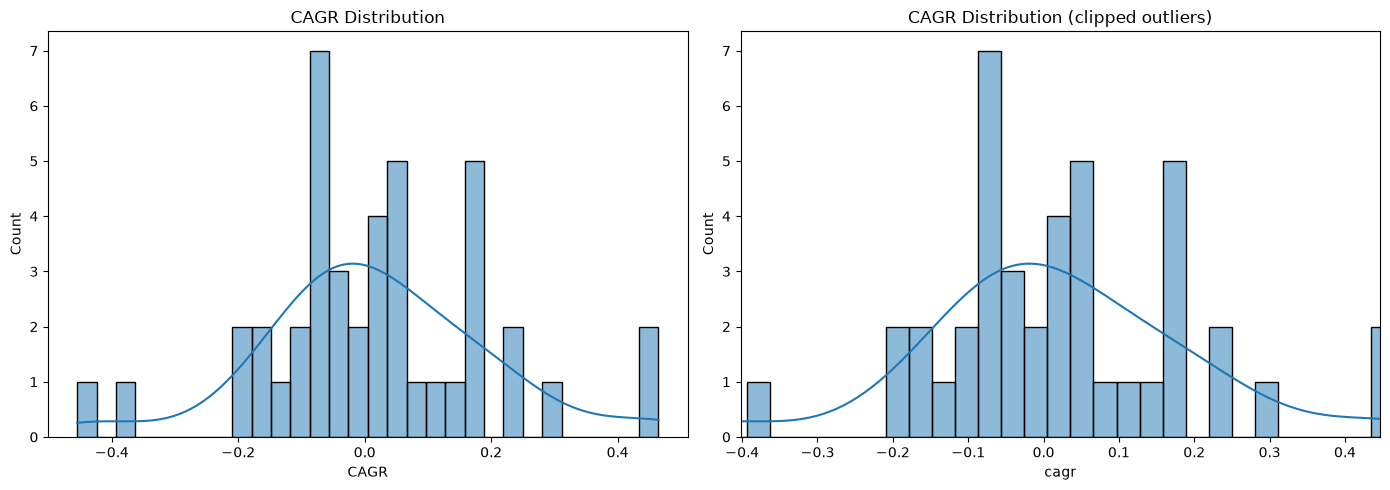

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Обычный
sns.histplot(df_filled["cagr"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("CAGR Distribution")
axes[0].set_xlabel("CAGR")

# Log-transformed (для сравнения)
sns.histplot(df_filled["cagr"].dropna(), bins=30, kde=True,
             log_scale=False, ax=axes[1])
axes[1].set_title("CAGR Distribution (clipped outliers)")
axes[1].set_xlim(df_filled["cagr"].quantile(0.02),
                  df_filled["cagr"].quantile(0.98)) #distribution density curve

plt.tight_layout()
plt.show()

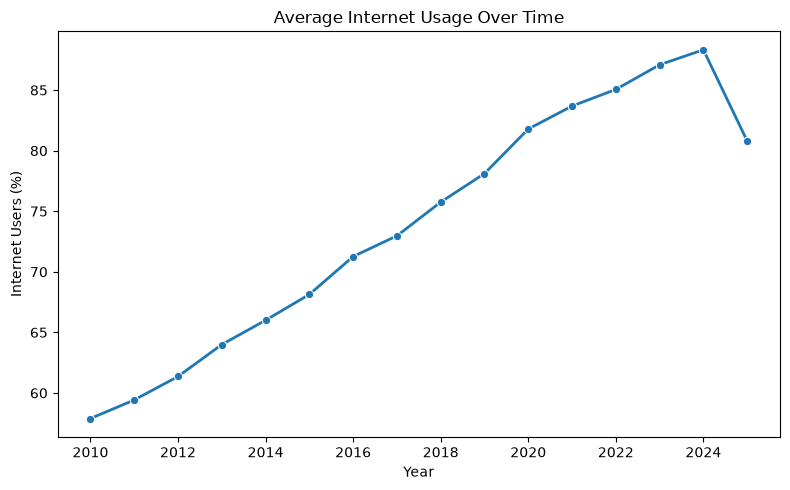

In [204]:
internet_yearly = (
    macro_wide
    .groupby("year")["internet_users_pct"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=internet_yearly,
    x="year",
    y="internet_users_pct",
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title("Average Internet Usage Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Internet Users (%)")

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3468\2610915665.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(


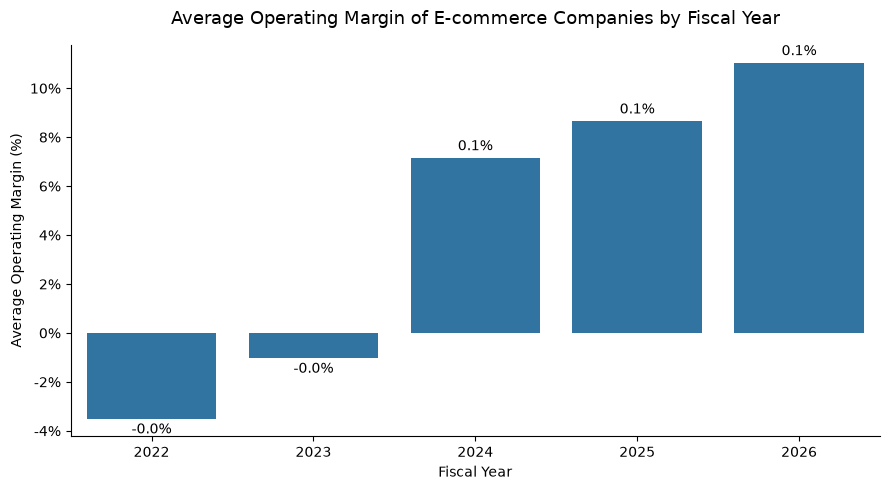

In [ ]:
yearly = (
    df_fin_full
    .groupby("fiscal_year")["operating_margin"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = sns.barplot(
    data=yearly,
    x="fiscal_year",
    y="operating_margin",
    ax=ax
)

# Подписи над столбцами
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set_title(
    "Average Operating Margin of E-commerce Companies by Fiscal Year",
    fontsize=13,
    pad=15 #отступ между заголовком и верхней частью графика
)

ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Average Operating Margin (%)")

# Если operating_margin хранится как 0.12 = 12%
ax.set_yticklabels(
    [f"{y:.0%}" for y in ax.get_yticks()]
)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

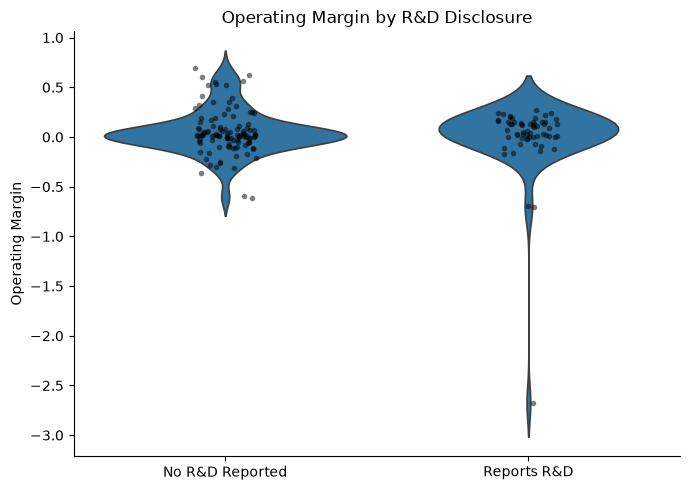

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

plot_df = df_fin_full[
    df_fin_full["operating_margin"].notna()
].copy()

plot_df["R&D Reporting"] = plot_df["has_rd"].map({
    1: "Reports R&D",
    0: "No R&D Reported"
})

sns.violinplot(
    data=plot_df,
    x="R&D Reporting",
    y="operating_margin",
    inner=None,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="R&D Reporting",
    y="operating_margin",
    color="black",
    alpha=0.5,
    size=4,
    ax=ax
)

ax.set_title("Operating Margin by R&D Disclosure")
ax.set_xlabel("")
ax.set_ylabel("Operating Margin")

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Violin plot показывает оценку плотности распределения.

Чем шире «скрипка» на определённой высоте, тем больше значений operating_margin находится около этого уровня.

Например:

* широкая часть около 0.10 означает, что много наблюдений имеют operating margin примерно 10%;
* узкая часть означает, что таких наблюдений мало.

In [216]:
df_fin_full.columns

Index(['company_id', 'ticker', 'fiscal_year', 'total_revenue', 'gross_profit',
       'operating_income', 'net_income', 'ebitda', 'research_dev',
       'total_assets', 'total_liabilities', 'cash_and_equivalents',
       'total_equity', 'operating_cash_flow', 'capex', 'free_cash_flow',
       'operating_margin', 'segment_x', 'country_code_x', 'has_rd',
       'rd_intensity'],
      dtype='str')

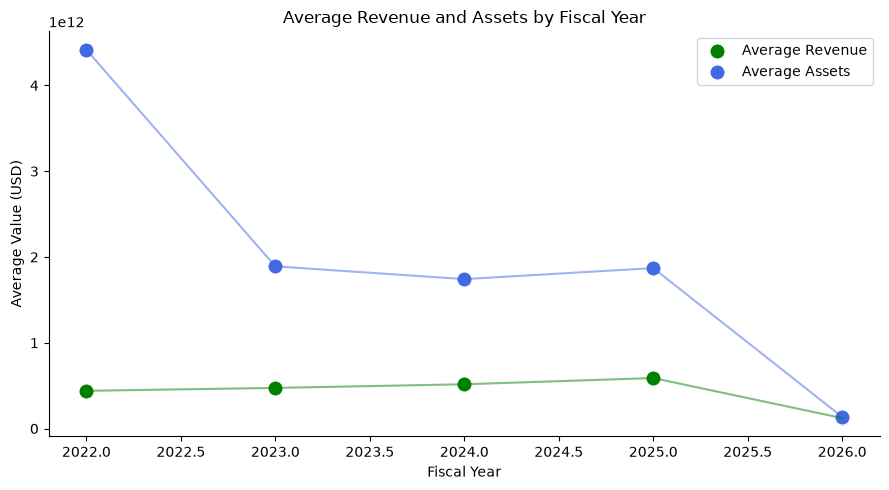

In [217]:
yearly_metrics = (
    df_fin_full
    .groupby("fiscal_year")[["total_revenue", "total_assets"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=yearly_metrics,
    x="fiscal_year",
    y="total_revenue",
    color="green",
    s=120,
    label="Average Revenue",
    ax=ax
)

sns.scatterplot(
    data=yearly_metrics,
    x="fiscal_year",
    y="total_assets",
    color="royalblue",
    s=120,
    label="Average Assets",
    ax=ax
)

ax.plot(
    yearly_metrics["fiscal_year"],
    yearly_metrics["total_revenue"],
    color="green",
    alpha=0.5
)

ax.plot(
    yearly_metrics["fiscal_year"],
    yearly_metrics["total_assets"],
    color="royalblue",
    alpha=0.5
)

ax.set_title(
    "Average Revenue and Assets by Fiscal Year"
)

ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Average Value (USD)")

ax.legend()

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Detailed plots**

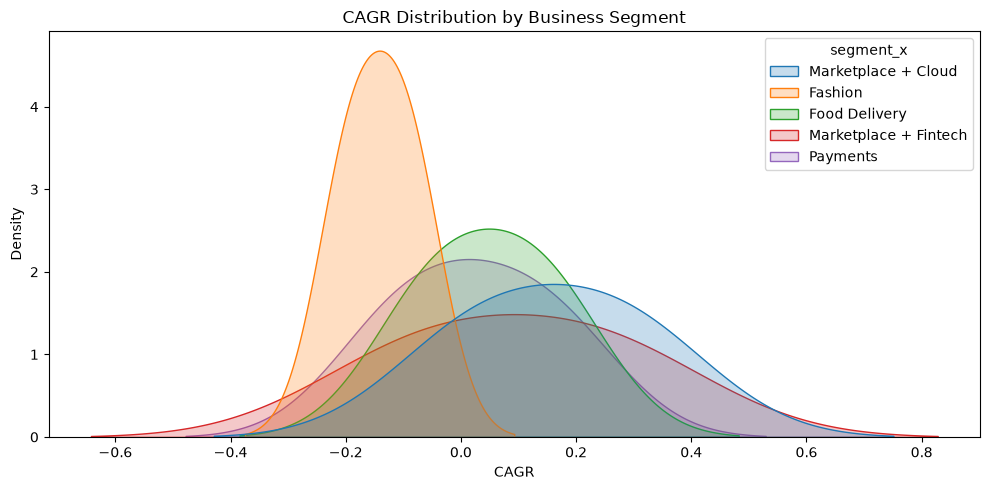

In [ ]:
top_segments = (
    df_filled["segment_x"]
    .value_counts()
    .head(5)
    .index
) # оставляем 5 самых многочисленных сегментов

plot_df = df_filled[
    df_filled["segment_x"].isin(top_segments) #оставляем только те строки, которые относяться к топу по сегментам
]

fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(
    data=plot_df,
    x="cagr",
    hue="segment_x", #разделяет данные групп по сегментам
    fill=True,
    alpha=0.25, #прозрачность заливки
    common_norm=False, #каждая группа нормируется отдельно так, что площадь под каждой её KDE-кривой равна 1. Это удобно, потому что мы хотим сравнивать именно форму распределений, а не количество компаний в сегменте.
    ax=ax
)

ax.set_title("CAGR Distribution by Business Segment")
ax.set_xlabel("CAGR")

plt.tight_layout()
plt.show()

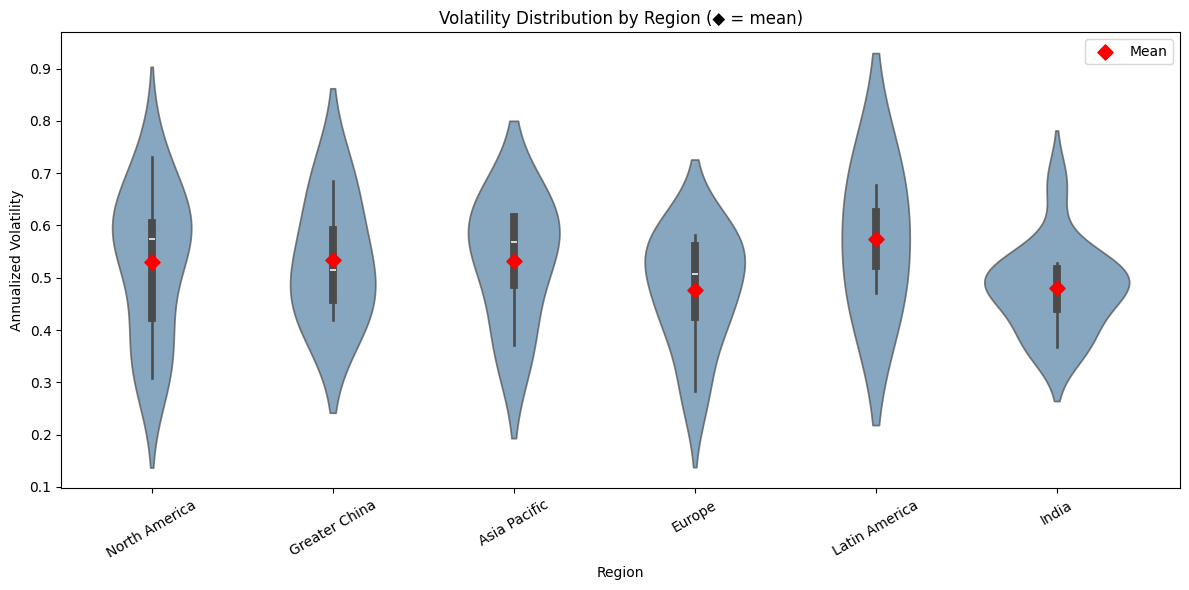

In [85]:
fig, ax = plt.subplots(figsize=(12, 6))

df_plot = df_filled[df_filled["annualized_volatility"] < df_filled["annualized_volatility"].quantile(0.95)]

sns.violinplot(data=df_plot, x="region_x", y="annualized_volatility",
               inner="box", ax=ax, color="steelblue", alpha=0.7)

# Добавляем mean поверх
means = df_plot.groupby("region_x")["annualized_volatility"].mean()
regions_order = df_plot["region_x"].unique()
for i, region in enumerate(ax.get_xticklabels()):
    r = region.get_text()
    if r in means.index:
        ax.scatter(i, means[r], color="red", zorder=5, s=60, marker="D", label="Mean" if i==0 else "")

ax.legend()
ax.set_title("Volatility Distribution by Region (◆ = mean)")
ax.set_xlabel("Region")
ax.set_ylabel("Annualized Volatility")
plt.xticks(rotation=30)
plt.tight_layout()

In [86]:
df_ecommerce.head()

,date,constituents,daily_return,index_level
0,2015-01-05,13,NaN,99.953267
1,2015-01-06,14,-0.022106,97.743667
2,2015-01-07,14,-0.046385,93.209870
3,2015-01-08,14,0.016463,94.744410
4,2015-01-09,14,-0.010356,93.763193


In [221]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

**At least 4 plots or outputs for a detailed overview. These should be presented in the form of comparisons: plotting several lines with different conditions on the same figure, printing statistics for subsets of data, plotting two graphs next to each other, etc.**

Проблема в том что
* e-commerce index — пункты индекса;
* internet users — проценты;
* GDP per capita — доллары;
* mobile subscriptions — число подписок на 100 человек.

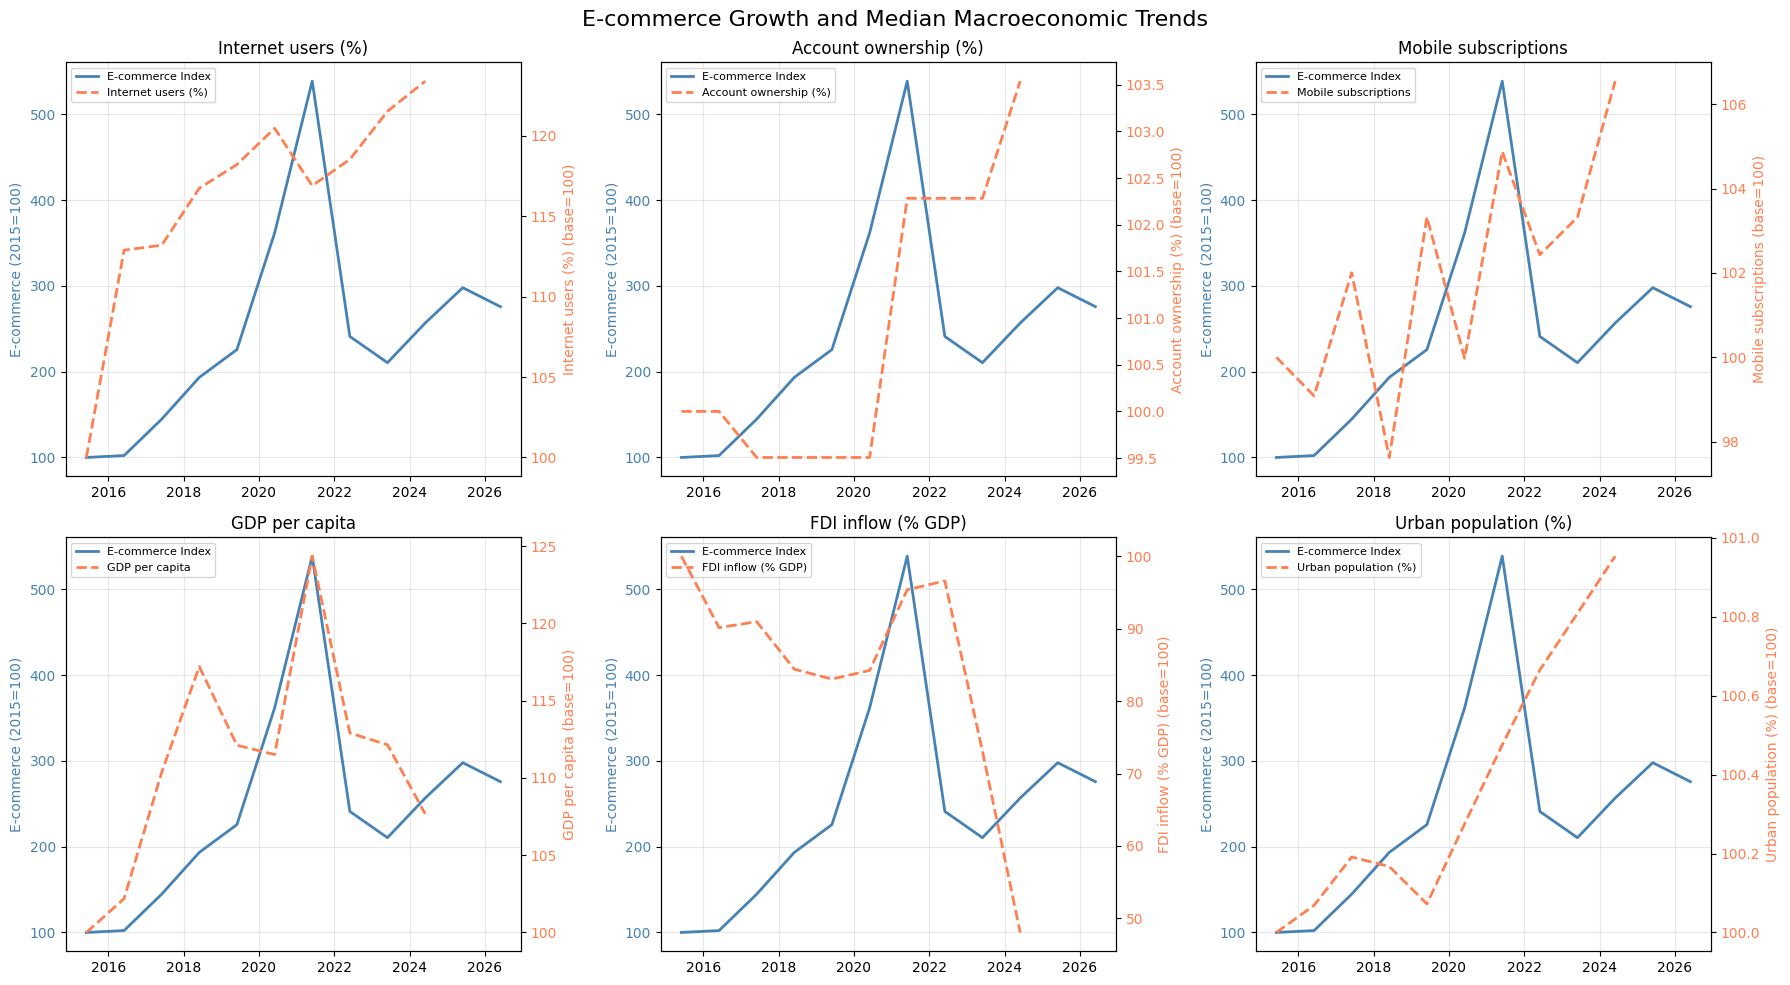

In [ ]:
START_YEAR = 2015
END_YEAR = 2024


ecom = df_ecommerce.copy()
ecom["date"] = pd.to_datetime(ecom["date"])
ecom = ecom[
    (ecom["date"].dt.year >= 2015)
]

# Переводим в годовую частоту
ecom_yearly = (
    ecom
    .assign(year=ecom["date"].dt.year) #создается новый столбец year
    .groupby("year")["index_level"]
    .mean()
    .reset_index()
)

ecom_yearly["date"] = pd.to_datetime(
    ecom_yearly["year"].astype(str) + "-06-01"
)

# Нормализация: начало периода = 100% и от нее уже удобно смотреть рост/падение
ecom_yearly["ecom_norm"] = (
    ecom_yearly["index_level"]
    / ecom_yearly["index_level"].iloc[0]
    * 100
)


indicators = {
    "internet_users_pct": "Internet users (%)",
    "account_ownership_pct_adult": "Account ownership (%)",
    "mobile_subs_per_100": "Mobile subscriptions",
    "gdp_per_capita_usd": "GDP per capita",
    "fdi_inflow_pct_gdp": "FDI inflow (% GDP)",
    "urban_population_pct": "Urban population (%)",
}


fig = plt.figure(figsize=(18, 10)) #общая фигура 18x10 дюймов
gs = GridSpec(2, 3, figure=fig) # наша сеточка

axes = []

for i in range(2):
    for j in range(3):
        axes.append(fig.add_subplot(gs[i, j])) #добавляем туда еще пустой графичек

"""
Здесь zip() попарно соединяет: - создает пару

первый ax с первым индикатором;
второй ax со вторым индикатором;
"""

for ax, (indicator, title) in zip(axes, indicators.items()):

    # ----- E-commerce -----

    ax.plot(
        ecom_yearly["date"],
        ecom_yearly["ecom_norm"],
        color="steelblue",
        linewidth=2,
        label="E-commerce Index"
    )

    ax.set_ylabel(
        "E-commerce (2015=100)",
        color="steelblue"
    )

    ax.tick_params(axis="y", labelcolor="steelblue") #подписываем левую ось

    # ----- Макропоказатель -----
    """
    Почему медиана, а не среднее? 
    Потому что макропоказатели по странам могут быть сильно асимметричными и содержать экстремальные значения.
    Медиана устойчивее
    То есть у нас из pivot tabple берется показатель для X года по странам и среди них именно медиана
    """
    macro = (
        macro_wide[
            (macro_wide["year"] >= START_YEAR) &
             (macro_wide["year"] <= END_YEAR)]
        .groupby("year")[indicator]
        .median()
        .reset_index())

    macro = macro.dropna()

    macro["date"] = pd.to_datetime(
        macro["year"].astype(int).astype(str) + "-06-01"
    )
    #нормализация
    macro["macro_norm"] = ( macro[indicator]/ macro.loc[macro["year"] == 2015, indicator].iloc[0]* 100)

    ax2 = ax.twinx() #чторая вертикальная ось

    ax2.plot(
        macro["date"],
        macro["macro_norm"],
        color="coral",
        linewidth=2,
        linestyle="--",
        label=title
    )

    ax2.set_ylabel(
        f"{title} (base=100)",
        color="coral"
    )

    ax2.tick_params(axis="y", labelcolor="coral")

    # ----- Оформление -----

    ax.set_title(title)

    ax.grid(alpha=0.3) #прозрачность сетки

    # Общая легенда внутри панели
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax.legend(
        lines1 + lines2,
        labels1 + labels2,
        fontsize=8,
        loc="upper left"
    )


fig.suptitle(
    "E-commerce Growth and Median Macroeconomic Trends",
    fontsize=16,
    y=0.98
)

plt.tight_layout()
plt.show()

---------------------

In [89]:
df_stick.head()

,company_id,ticker,date,open,high,low,close,adj_close,volume
0,affirm,AFRM,2021-01-13,90.900002,103.000000,90.010002,96.364998,96.364998,25159000
1,affirm,AFRM,2021-01-14,103.500000,137.979996,101.000000,114.940002,114.940002,20858700
2,affirm,AFRM,2021-01-15,123.054001,127.239998,107.000000,117.000000,117.000000,8310700
3,affirm,AFRM,2021-01-19,117.000000,117.675003,108.000000,110.989998,110.989998,3304900
4,affirm,AFRM,2021-01-20,110.000000,112.000000,103.250000,106.209999,106.209999,5091400


In [90]:
df_stick['date'].min()

'2015-01-01'

If $1 had been invested equally across all e-commerce companies in 2015, how would that investment have evolved over time?

Figure 2 shows the evolution of an equal-weighted portfolio consisting of e-commerce companies that were publicly traded by the end of 2015.

In [ ]:
START_YEAR = 2015
END_YEAR = 2024
FORMATION_DATE = pd.Timestamp("2015-12-31") #В портфель включаются только компании, у которых были биржевые данные не позднее 31 декабря 2015 года.

prices = df_stick.copy()

prices["date"] = pd.to_datetime(prices["date"])


first_dates = (
    prices
    .groupby("ticker")["date"]
    .min()
)

# Оставляем компании, уже торговавшиеся к концу 2015 года
eligible = first_dates[
    first_dates <= FORMATION_DATE
].index

# Фильтрация компаний
prices = prices[
    prices["ticker"].isin(eligible)
].copy()
"""
Если включить компании, вышедшие на биржу позже, например в 2020 году, состав портфеля будет постоянно расширяться.

Тогда рост портфеля может отражать не только рост акций, но и добавление новых компаний.
"""
# Ограничиваем период анализа
prices = prices[
    (prices["date"].dt.year >= START_YEAR) &
    (prices["date"].dt.year <= END_YEAR)
].copy()

# Сортировка
prices = prices.sort_values(["ticker", "date"])

print(f"Number of eligible companies: {len(eligible)}")
# ======================================
# 3. Проверка покрытия данных
# ======================================

n_companies = (
    prices
    .groupby("date")["ticker"]
    .nunique()
)

print(
    f"Companies per day: "
    f"min={n_companies.min()}, "
    f"max={n_companies.max()}"
)


prices["normalized"] = (
    prices["adj_close"]
    / prices.groupby("ticker")["adj_close"].transform("first")
    * 100
)
#"Во сколько раз вырос бы портфель, если бы мы инвестировали одинаковую сумму в каждую компанию?"

price_wide = prices.pivot(
    index="date",
    columns="ticker",
    values="normalized"
)
price_wide = price_wide.ffill()

equal_weight = (
    price_wide
    .mean(axis=1)
    .reset_index(name="normalized")
)
# ======================================
# 6. Подготовка E-commerce Index
# ======================================

ecom_compare = df_ecommerce.copy()

ecom_compare["date"] = pd.to_datetime(
    ecom_compare["date"]
)

ecom_compare = ecom_compare[
    (ecom_compare["date"].dt.year >= START_YEAR) &
    (ecom_compare["date"].dt.year <= END_YEAR)
].copy()

ecom_compare["norm"] = (
    ecom_compare["index_level"]
    / ecom_compare["index_level"].iloc[0]
    * 100
)

Number of eligible companies: 19
Companies per day: min=1, max=19


In [92]:
coverage = (
    prices
    .groupby("date")["ticker"]
    .nunique()
    .reset_index(name="n_companies")
)

display(coverage.head(20))

,date,n_companies
0,2015-01-01,1
1,2015-01-02,13
2,2015-01-05,14
3,2015-01-06,14
4,2015-01-07,14
5,2015-01-08,14
6,2015-01-09,14
7,2015-01-12,13
8,2015-01-13,14
9,2015-01-14,14


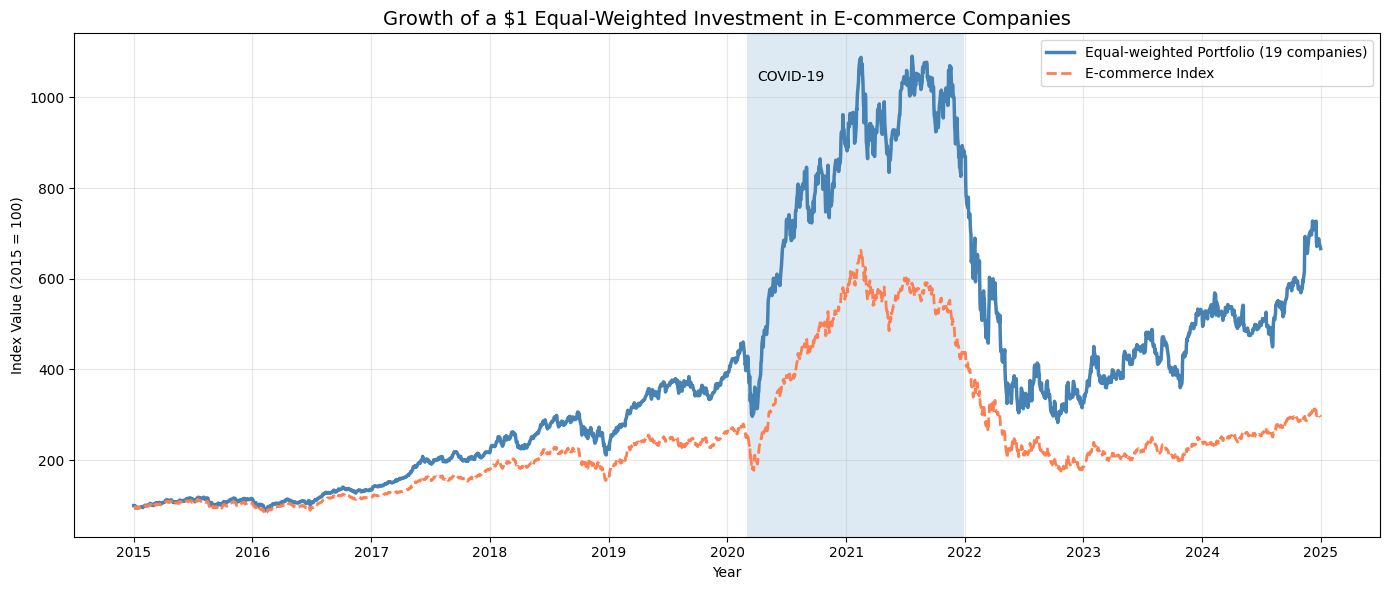

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Equal-weighted portfolio
ax.plot(
    equal_weight["date"],
    equal_weight["normalized"],
    linewidth=2.5,
    color="steelblue",
    label=(
        f"Equal-weighted Portfolio "
        f"({len(eligible)} companies)"
    )
)

# E-commerce index
ax.plot(
    ecom_compare["date"],
    ecom_compare["norm"],
    linewidth=2,
    linestyle="--",
    color="coral",
    label="E-commerce Index"
)

# COVID period
ax.axvspan( #вертикальная полупрозрачная штука
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-12-31"),
    alpha=0.15
)

# Подпись COVID
ax.text(
    pd.Timestamp("2020-04-01"),
    equal_weight["normalized"].max() * 0.95, #ставит подпись примерно на уровне 95%
    "COVID-19",
    fontsize=10
)


ax.set_title(
    "Growth of a $1 Equal-Weighted Investment in E-commerce Companies",
    fontsize=14
)

ax.set_ylabel("Index Value (2015 = 100)")
ax.set_xlabel("Year")

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

----------------

. Violin plot — что он показывает
Это как раз хороший график. Вот что читается:

Все регионы имеют медианную волатильность ~0.5-0.6 — различия между регионами меньше чем кажется
North America и Latin America имеют самый широкий хвост вверх (есть очень волатильные компании)
India интересна — узкое распределение, концентрация около 0.45-0.5, мало выбросов
Europe — самая низкая медиана и компактное распределение

Это уже частичный ответ на H2: различия в волатильности между регионами есть, но не драматические. Что и надо будет проверить статистически.

-------------

If $1 had been invested equally in e-commerce companies from each region, how would these portfolios have evolved?

In [94]:
region_map = (
    df_filled[
        ["ticker_x", "region_x"]
    ]
    .drop_duplicates()
    .rename(columns={"ticker_x": "ticker"})
)

prices_region = prices.merge(
    region_map,
    on="ticker",
    how="left"
)

In [ ]:
regional_indices = []

for region, group in prices_region.groupby("region_x"): #group - строки только данного региона

    wide = (
        group
        .pivot(index="date",
               columns="ticker",
               values="normalized")
        .ffill()
    )

    idx = wide.mean(axis=1)

    regional_indices.append(
        pd.DataFrame({
            "date": idx.index,
            "index": idx.values,
            "region": region
        })
    )

regional_indices = pd.concat(regional_indices) 

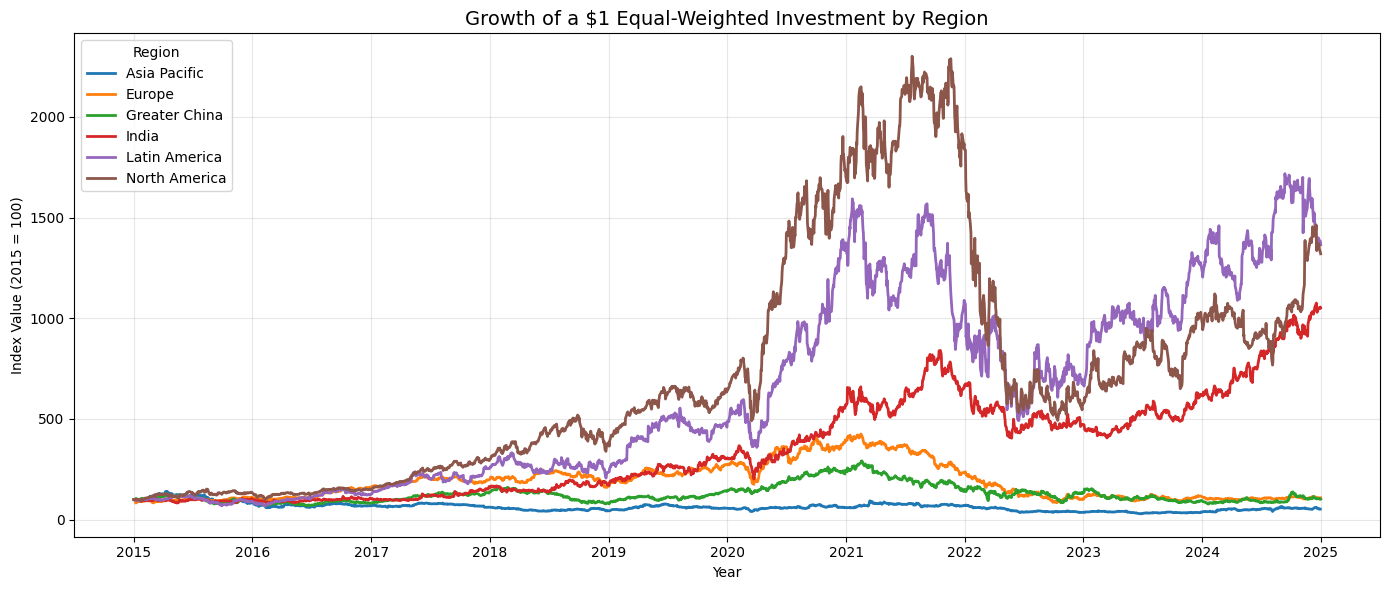

In [96]:
fig, ax = plt.subplots(figsize=(14, 6))

for region, group in regional_indices.groupby("region"):

    ax.plot(
        group["date"],
        group["index"],
        linewidth=2,
        label=region
    )

ax.set_title(
    "Growth of a $1 Equal-Weighted Investment by Region",
    fontsize=14
)

ax.set_ylabel("Index Value (2015 = 100)")
ax.set_xlabel("Year")

ax.grid(alpha=0.3)

# Вот это добавляет описание цветов
ax.legend(title="Region")

plt.tight_layout()
plt.show()

------

--------------

из дневных цен делаешь годовую таблицу последних цен по каждой компании, а потом находишь первую годовую цену для каждого тикера

In [222]:
prices = df_stick.copy()

prices["date"] = pd.to_datetime(prices["date"])
prices["year"] = prices["date"].dt.year

yearly = (
    prices
    .sort_values(["ticker", "date"])
    .groupby(["ticker", "year"])
    .last()
    .reset_index()
)
first_price = (
    yearly
    .groupby("ticker")["adj_close"]
    .first()
)

In [191]:
yearly.columns

Index(['ticker', 'year', 'company_id', 'date', 'open', 'high', 'low', 'close',
       'adj_close', 'volume'],
      dtype='object')

In [223]:
yearly["first_price"] = yearly["ticker"].map(first_price) #"Возьми тикер и найди для него значение в first_price."
yearly.groupby("ticker")["year"].min()
first_year = (
    yearly
    .groupby("ticker")["year"]
    .first()
)

yearly["first_year"] = yearly["ticker"].map(first_year)

yearly["years_elapsed"] = (
    yearly["year"]
    - yearly["first_year"]
)

# CAGR нельзя считать для n=0
yearly = yearly[yearly["years_elapsed"] > 0]

yearly["cagr"] = (
    (yearly["adj_close"] / yearly["first_price"])
    ** (1 / yearly["years_elapsed"])
    - 1
)

In [193]:
yearly.columns

Index(['ticker', 'year', 'company_id', 'date', 'open', 'high', 'low', 'close',
       'adj_close', 'volume', 'first_price', 'first_year', 'years_elapsed',
       'cagr'],
      dtype='object')

In [224]:
regions = (
    df_filled[
        ["ticker_x", "region_x"]
    ].copy()
    .drop_duplicates()
    .rename(columns={"ticker_x": "ticker"})
)

yearly = yearly.merge(
    regions,
    on="ticker",
    how="left"
)

In [195]:
yearly.columns

Index(['ticker', 'year', 'company_id', 'date', 'open', 'high', 'low', 'close',
       'adj_close', 'volume', 'first_price', 'first_year', 'years_elapsed',
       'cagr', 'region_x'],
      dtype='object')

In [196]:
regions["region_x"].unique()

array(['North America', 'Greater China', 'Asia Pacific', 'Europe',
       'Latin America', 'India'], dtype=object)

C:\Users\User\AppData\Local\Temp\ipykernel_3468\2725244801.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x1800 with 0 Axes>

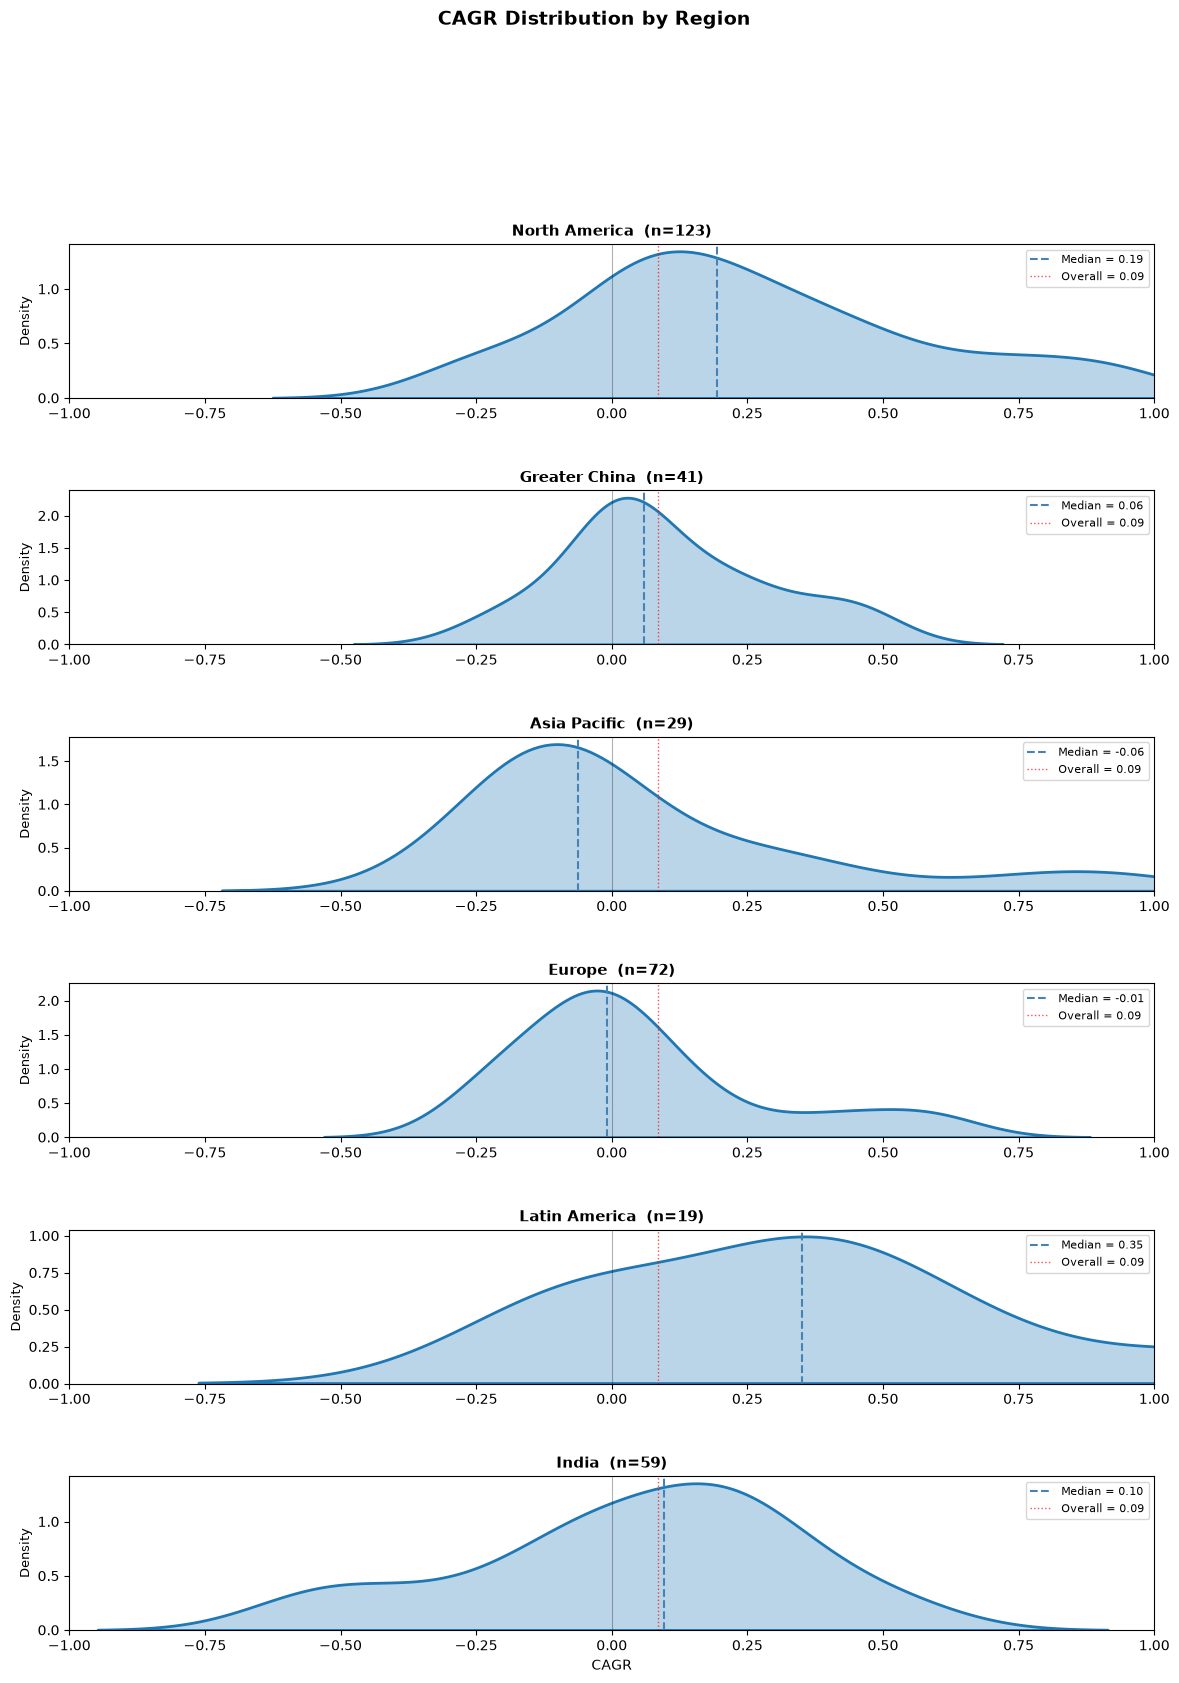

In [225]:
regions = df_filled["region_x"].dropna().unique()
n = len(regions)

fig = plt.figure(figsize=(14, 3 * n))
gs = GridSpec(n, 1, hspace=0.6)

overall_median = yearly["cagr"].median()

for i, region in enumerate(regions):
    ax = fig.add_subplot(gs[i])

    data = yearly[yearly["region_x"] == region]["cagr"]
    low, high = data.quantile(0.05), data.quantile(0.95)
    data_clipped = data.clip(low, high)

    sns.kdeplot(data_clipped, ax=ax, fill=True, alpha=0.3, linewidth=2)

    # Медиана региона
    region_median = data.median()
    ax.axvline(region_median, color="steelblue", linestyle="--",
               linewidth=1.5, label=f"Median = {region_median:.2f}")

    # Общая медиана для сравнения
    ax.axvline(overall_median, color="red", linestyle=":",
               linewidth=1, alpha=0.7, label=f"Overall = {overall_median:.2f}")

    ax.axvline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.3)

    ax.set_title(f"{region}  (n={len(data)})", fontsize=11, fontweight="bold")
    ax.set_xlabel("CAGR" if i == n-1 else "")
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(-1, 1)  # одинаковый масштаб для всех

fig.suptitle("CAGR Distribution by Region", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

После того как мы перешли от "последнего CAGR" к company-year CAGR, KDE теперь отвечает на вопрос:

Как распределялись темпы роста компаний из разных регионов на протяжении всего периода?

Instead of comparing only the latest company outcomes, we analysed the distribution of annualized stock growth rates across all company-year observations between 2015 and 2024. This approach captures the full evolution of firms throughout the sample period and provides a more representative picture of regional performance differences.

-----

In [217]:
macro_wide.head()

indicator_name,country_code,year,account_ownership_pct_adult,fdi_inflow_pct_gdp,gdp_per_capita_usd,gdp_total_usd,internet_users_pct,mobile_subs_per_100,population_total,urban_population_pct
0,AR,2010,33.130217,2.675162,10260.131311,4.236274e+11,45.000000,138.251643,41288694.0,90.993005
1,AR,2011,33.130217,2.044660,12704.283182,5.301581e+11,51.000000,145.511068,41730660.0,91.107229
2,AR,2012,33.130217,2.806672,12949.717487,5.459824e+11,55.799999,152.573580,42161721.0,91.204122
3,AR,2013,33.130217,1.779206,12963.675773,5.520251e+11,59.900002,158.190774,42582455.0,91.301451
4,AR,2014,50.197294,0.962407,12233.144412,5.263197e+11,64.699997,142.325481,43024071.0,91.397535


---------------

------------------

In [ ]:
from scipy.cluster.vq import kmeans, vq, whiten
import matplotlib.pyplot as plt


-----

------------

In [237]:
from scipy.stats import spearmanr

In [ ]:
fin_growth = (
    df_fin_full
    .sort_values(["company_id", "fiscal_year"])
    .copy()
)

fin_growth["annual_revenue_growth"] = (
    fin_growth
    .groupby("company_id")["total_revenue"]
    .pct_change(fill_method=None) #calculate redarding to the previous row and return the change in the percantage
    #fill_method - None since we can accidentally to construct a growth but it wasn't
)

fin_growth = (
    fin_growth[
        [
            "company_id",
            "ticker",
            "fiscal_year",
            "total_revenue",
            "annual_revenue_growth"
        ]
    ]
    .rename(columns={"fiscal_year": "year"})
    .dropna(subset=["annual_revenue_growth"]) #for the first year there is no value -> need to delete
    .copy()
)

fin_growth.head()

,company_id,ticker,year,total_revenue,annual_revenue_growth
1,affirm,AFRM,2023,1.587985e+09,0.176902
2,affirm,AFRM,2024,2.322999e+09,0.462860
3,affirm,AFRM,2025,3.224412e+09,0.388038
5,alibaba,BABA,2023,8.686870e+11,0.018316
6,alibaba,BABA,2024,9.411680e+11,0.083437


In [ ]:

prices_daily = df_stick.copy()

prices_daily["date"] = pd.to_datetime(
    prices_daily["date"],
    errors="coerce"
)

prices_daily["adj_close"] = pd.to_numeric(
    prices_daily["adj_close"],
    errors="coerce" #если дата записана неверно, она превращается в NaT, а не в ошибку
)

prices_daily = (
    prices_daily
    .dropna(subset=["ticker", "date", "adj_close"])
    .query("adj_close > 0") #sql синтаксис чтобы убрать нулевые и отриц значения
    .drop_duplicates(subset=["ticker", "date"], keep="last") #чтобы на 1 дату остались именно индивидуальные компании (оставляется первая)
    .sort_values(["ticker", "date"])
    .copy()
)

prices_daily["year"] = prices_daily["date"].dt.year


# One observation for each company-year
annual_stock = (
    prices_daily
    .groupby(["ticker", "year"], as_index=False)
    .agg(
        first_date=("date", "first"),
        last_date=("date", "last"),
        first_price=("adj_close", "first"),
        last_price=("adj_close", "last"),
        trading_days=("adj_close", "count")
    )
) #делаем это вручную так как много дат в prices_daily


# Annual stock return calculated from daily prices
annual_stock["annual_stock_return"] = (
    annual_stock["last_price"]
    / annual_stock["first_price"]
    - 1
)

annual_stock.head()

,ticker,year,first_date,last_date,first_price,last_price,trading_days,annual_stock_return
0,4755.T,2015,2015-01-05,2015-12-30,1625.241089,1360.121948,244,-0.163126
1,4755.T,2016,2016-01-04,2016-12-30,1338.794312,1114.801270,245,-0.167310
2,4755.T,2017,2017-01-04,2017-12-29,1138.644897,1009.234680,253,-0.113653
3,4755.T,2018,2018-01-01,2018-12-31,1009.234680,723.959412,261,-0.282665
4,4755.T,2019,2019-01-04,2019-12-30,714.122986,924.127808,241,0.294074


In [305]:
h1_panel = (
    fin_growth
    .merge(
        annual_stock[
            [
                "ticker",
                "year",
                "first_price",
                "trading_days",
                "annual_stock_return"
            ]
        ],
        on=["ticker", "year"],
        how="inner"
    )
)

h1_panel = h1_panel.dropna(
    subset=[
        "annual_revenue_growth",
        "annual_stock_return"
    ]
).copy()
h1_panel = h1_panel[
    h1_panel["year"] <= 2025
].copy()
print("Company-year observations:", len(h1_panel))
print("Companies:", h1_panel["company_id"].nunique())
print("Years:", sorted(h1_panel["year"].unique()))

h1_panel.head()

Company-year observations: 121
Companies: 43
Years: [np.int64(2023), np.int64(2024), np.int64(2025)]


,company_id,ticker,year,total_revenue,annual_revenue_growth,first_price,trading_days,annual_stock_return
0,affirm,AFRM,2023,1.587985e+09,0.176902,9.100000,250,4.400000
1,affirm,AFRM,2024,2.322999e+09,0.462860,46.599998,252,0.306867
2,affirm,AFRM,2025,3.224412e+09,0.388038,62.509998,250,0.190690
3,alibaba,BABA,2023,8.686870e+11,0.018316,87.352951,250,-0.145989
4,alibaba,BABA,2024,9.411680e+11,0.083437,71.953621,252,0.158812


In [ ]:
x_low, x_high = h1_panel["annual_revenue_growth"].quantile([0.02, 0.98])
y_low, y_high = h1_panel["annual_stock_return"].quantile([0.02, 0.98]) #cutting off extreme emissions, только чтобы построить красивый график, для гипотезы данные используются полные

plot_data = h1_panel[
    h1_panel["annual_revenue_growth"].between(x_low, x_high)
    &
    h1_panel["annual_stock_return"].between(y_low, y_high)
].copy() #берем данные между этими квантилями - как раз 96% 

#далее все переводим в проценты
plot_data["annual_revenue_growth_pct"] = (
    plot_data["annual_revenue_growth"] * 100
)

plot_data["annual_stock_return_pct"] = (
    plot_data["annual_stock_return"] * 100
)

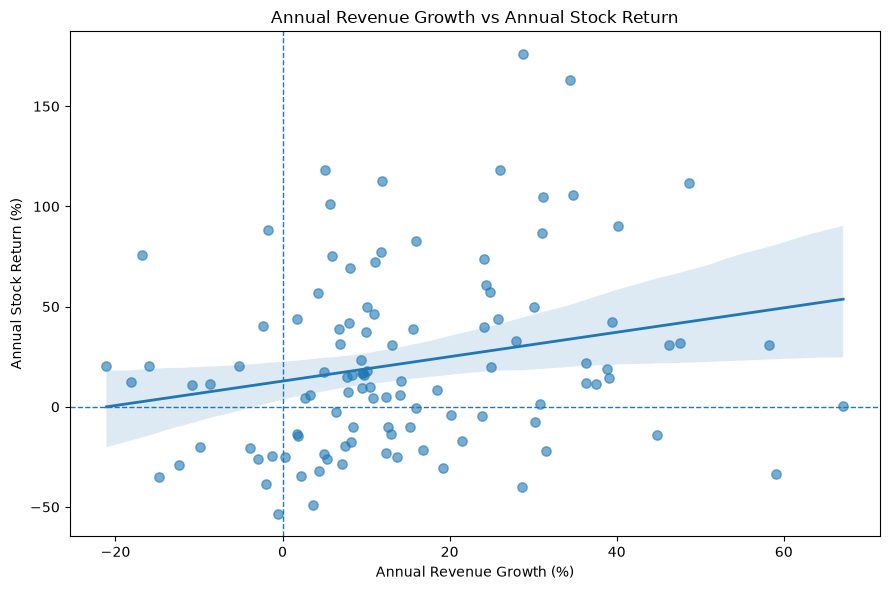

In [ ]:
plt.figure(figsize=(9, 6))

sns.regplot( #одновременно строит scatter plot и лин регрессию
    data=plot_data,
    x="annual_revenue_growth_pct",
    y="annual_stock_return_pct",
    scatter_kws={ #параметры для точек
        "alpha": 0.6,
        "s": 45
    },
    line_kws={#для линии
        "linewidth": 2
    }
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title(
    "Annual Revenue Growth vs Annual Stock Return"
)

plt.xlabel("Annual Revenue Growth (%)")
plt.ylabel("Annual Stock Return (%)")

plt.tight_layout()
plt.show()

Причины почему спирсон:

* финансовые данные редко нормально распределены;
* присутствуют выбросы;
* зависимость может быть монотонной, но нелинейной;
* коэффициент Спирмена работает с рангами, поэтому менее чувствителен к экстремальным значениям.

In [ ]:
import numpy as np
from scipy.stats import spearmanr

def company_bootstrap_spearman(
    data,
    cluster_col="ticker", 
    n_boot=5000,
    seed=42
):
    clean_data = (
        data[
            [
                cluster_col,
                "annual_revenue_growth",
                "annual_stock_return"
            ]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    # Один раз создаём массивы для каждой компании
    company_groups = [
        (
            group["annual_revenue_growth"].to_numpy(),
            group["annual_stock_return"].to_numpy()
        )
        for _, group in clean_data.groupby(cluster_col, sort=False)
    ]

    n_companies = len(company_groups)
    rng = np.random.default_rng(seed) #генерируею случайные индексы компаний

    bootstrap_corrs = np.empty(n_boot)# сюдя будут записываться результаты корреляции в компании

    for i in range(n_boot): #основной bootsrtrap цикл
        sampled_indices = rng.integers( #вот здесь как раз rng
            low=0,
            high=n_companies,
            size=n_companies
        ) #создает массив случайных индексов компаний

        x_sample = np.concatenate([ #берем для компании annual_revenue_growth
            company_groups[index][0]
            for index in sampled_indices
        ])

        y_sample = np.concatenate([ #здесь annual_stock_return
            company_groups[index][1]
            for index in sampled_indices
        ])

        bootstrap_corrs[i] = spearmanr(
            x_sample,
            y_sample
        ).statistic #берем именно коэфициент Спирмена так как по нему строится бутстрап

    bootstrap_corrs = bootstrap_corrs[
        np.isfinite(bootstrap_corrs)
    ] #оставляем только конечные числа

    return np.percentile(
        bootstrap_corrs,
        [2.5, 50, 97.5]
    )


ci_low, bootstrap_corr, ci_high = (
    company_bootstrap_spearman(
        h1_panel,
        cluster_col="ticker",
        n_boot=5000
    )
)

print(f"Bootstrap median rho: {bootstrap_corr:.4f}")
print(
    f"95% cluster bootstrap CI: "
    f"[{ci_low:.4f}, {ci_high:.4f}]"
)

Bootstrap median rho: 0.2229
95% cluster bootstrap CI: [0.0763, 0.3732]


В большинстве возможных выборок компаний коэффициент Спирмена находился бы примерно между 0.08 и 0.37.

In [285]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(
    h1_panel["annual_revenue_growth"],
    h1_panel["annual_stock_return"],
    nan_policy="omit"
)

print("Spearman's Rank Correlation Coefficient Test")
print("--------------------------------------------")
print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

Spearman's Rank Correlation Coefficient Test
--------------------------------------------
Spearman correlation: 0.2190
P-value: 0.0149


-------------

Кластер 0

центр =
(1.93, 1.80, 1.77, 1.40)

Кластер 1

центр =
(-0.80, -0.53, -0.57, -0.33)

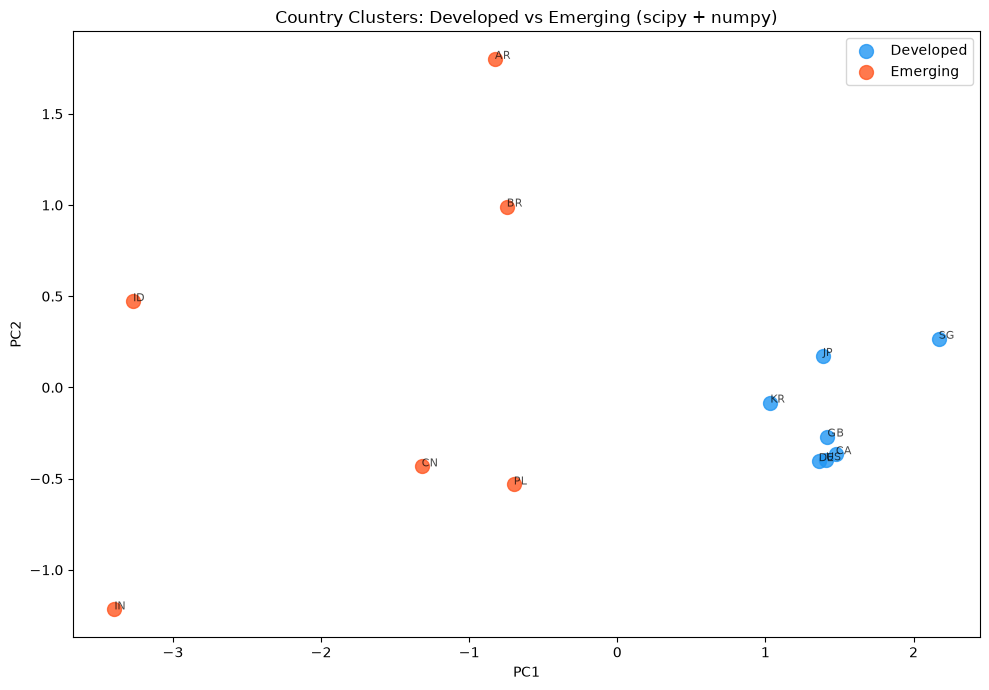

In [ ]:

features = ['gdp_per_capita_usd', 'internet_users_pct',
            'account_ownership_pct_adult', 'urban_population_pct']

country_df = macro_wide.groupby('country_code')[features].mean().reset_index() #берем среднее по данным


X = country_df[features].values
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)  # StandardScaler - > mean становиться 0


centroids, _ = kmeans(X_scaled, 2, seed=42) #автоматически 2 группы стран которые похожи на себя в рамках одной группы -> возвращает центра группы
labels, _ = vq(X_scaled, centroids) #и как раз для каждой страны подбирает первый или второй центроид
country_df['cluster'] = labels

#но непонятно 0 - это богатые или бедные, а GDP per capita — самый распространенный показатель уровня экономического развития.
cluster_gdp = country_df.groupby('cluster')['gdp_per_capita_usd'].mean()
developed_cluster = cluster_gdp.idxmax() #У какого кластера средний GDP самый большой?
country_df['market_type'] = country_df['cluster'].apply(
    lambda x: 'Developed' if x == developed_cluster else 'Emerging'
)


X_centered = X_scaled - X_scaled.mean(axis=0) #сдвинем данные к среднему в нуле
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
coords = X_centered @ Vt.T[:, :2]
country_df['pca1'] = coords[:, 0]
country_df['pca2'] = coords[:, 1]

#coords[:, 0] — первая колонка координат, то есть PC1.
#coords[:, 1] — вторая колонка координат, то есть PC2.

colors = {'Developed': '#2196F3', 'Emerging': '#FF5722'}
plt.figure(figsize=(10, 7))
for mtype, group in country_df.groupby('market_type'):
    plt.scatter(group['pca1'], group['pca2'],
                label=mtype, color=colors[mtype], s=100, alpha=0.8)
    for _, row in group.iterrows():
        plt.annotate(row['country_code'], (row['pca1'], row['pca2']), #подписи для стран
                     fontsize=8, alpha=0.7)

plt.title('Country Clusters: Developed vs Emerging (scipy + numpy)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()


In [288]:
country_df.head()

indicator_name,country_code,gdp_per_capita_usd,internet_users_pct,account_ownership_pct_adult,urban_population_pct,cluster,market_type,pca1,pca2
0,AR,12346.616902,72.486032,51.638147,91.662565,1,Emerging,-0.826182,1.801343
1,BR,10217.013591,65.512261,69.765015,86.155715,1,Emerging,-0.745901,0.991605
2,CA,49415.049281,89.891335,98.449642,81.640179,0,Developed,1.475929,-0.366084
3,CN,9596.724177,61.797293,78.448970,59.737899,1,Emerging,-1.320282,-0.433032
4,DE,47936.568359,87.076950,98.907236,81.057789,0,Developed,1.359673,-0.404132


In [ ]:


company_country = (
    df_filled[
        ["company_id", "country_code_x"]
    ]
    .rename(columns={"country_code_x": "country_code"})
    .dropna()
    .drop_duplicates()
)

duplicate_companies = (
    company_country["company_id"]
    .duplicated(keep=False) #Есть ли компании,которые записаны сразу для нескольких стран?
)

if duplicate_companies.any():
    problem_companies = (
        company_country.loc[
            duplicate_companies,
            "company_id"
        ]
        .unique()
    )

    raise ValueError(
        f"Several countries found for companies: {problem_companies}"
    )

df_stock_copy = df_stick.copy()

df_stock_copy["date"] = pd.to_datetime(
    df_stock_copy["date"],
    errors="coerce"
)

df_stock_copy["adj_close"] = pd.to_numeric(
    df_stock_copy["adj_close"],
    errors="coerce"
)

df_stock_copy = (
    df_stock_copy
    .dropna(subset=["company_id", "date", "adj_close"])
    .loc[lambda df: df["adj_close"] > 0]
    .sort_values(["company_id", "date"])
    .copy()
)


df_stock_copy = df_stock_copy.merge(
    company_country,
    on="company_id",
    how="left",
    validate="many_to_one" #у одной компании должна быть только одна страна.
)

df_stock_copy = df_stock_copy.merge(
    country_df[
        ["country_code", "market_type"]
    ],
    on="country_code",
    how="left",
    validate="many_to_one"
)

missing_market_type = df_stock_copy["market_type"].isna().sum()

print("Rows without market type:", missing_market_type)

print(
    df_stock_copy[
        ["company_id", "country_code", "market_type"]
    ]
    .drop_duplicates()
    .sort_values(["market_type", "country_code", "company_id"])
)



df_stock_copy["log_return"] = (
    df_stock_copy
    .groupby("company_id")["adj_close"]
    .transform(lambda x: np.log(x).diff()) #считаем ежеденевную лог доходность
)

df_stock_copy["rolling_vol"] = (
    df_stock_copy
    .groupby("company_id")["log_return"]
    .transform(
        lambda x: x.rolling(
            window=252,
            min_periods=126
        ).std() * np.sqrt(252)
    )
)

df_stock_copy["year"] = df_stock_copy["date"].dt.year

Rows without market type: 0
         company_id country_code market_type
69197       shopify           CA   Developed
81700       zalando           DE   Developed
8447             ao           GB   Developed
11317          asos           GB   Developed
14187    autotrader           GB   Developed
19637        boohoo           GB   Developed
52732         ocado           GB   Developed
62509       rakuten           JP   Developed
27686       coupang           KR   Developed
67046           sea           SG   Developed
0            affirm           US   Developed
5590         amazon           US   Developed
17003         block           US   Developed
23675       carvana           US   Developed
25948         chewy           US   Developed
29967      doordash           US   Developed
32600          ebay           US   Developed
35457          etsy           US   Developed
44768     instacart           US   Developed
55602        paypal           US   Developed
65303       revolve        

In [ ]:
company_year_vol = (
    df_stock_copy
    .groupby(
        [
            "company_id",
            "country_code",
            "market_type",
            "year"
        ]
    )["rolling_vol"]
    .median() # берем медиану для волатильности 
    .reset_index()
    .dropna()
)

vol_by_year = ( # Эта таблица удобна для графика: можно построить две линии — Developed и Emerging — по годам.
    company_year_vol
    .groupby(["year", "market_type"])["rolling_vol"]
    .median()
    .reset_index()
)
# Одно значение на компанию
vol_per_company = ( #тут комании группируются без года
    df_stock_copy
    .groupby(
        [
            "company_id",
            "country_code",
            "market_type"
        ]
    )["rolling_vol"]
    .median()
    .reset_index()
    .dropna()
)

# Одно значение на страну
vol_per_country = ( #и все компании группируем по стране и берем там медиану
    vol_per_company
    .groupby(
        ["country_code", "market_type"]
    )["rolling_vol"]
    .median()
    .reset_index()
)

print(
    vol_per_country
    .sort_values(["market_type", "rolling_vol"])
)

   country_code market_type  rolling_vol
8            JP   Developed     0.370672
9            KR   Developed     0.386022
4            DE   Developed     0.406191
5            GB   Developed     0.470082
2            CA   Developed     0.538213
12           US   Developed     0.551225
11           SG   Developed     0.590839
10           PL    Emerging     0.373290
0            AR    Emerging     0.440336
7            IN    Emerging     0.444997
3            CN    Emerging     0.529567
1            BR    Emerging     0.626418
6            ID    Emerging     0.630824


Permutation test — проверяет, статистически значима ли разница.
Cohen’s d — показывает размер эффекта, то есть насколько большая разница.

In [ ]:
def cohen_d(x, y):
    """
    Cohen's d.
    Positive value means x has the higher mean.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    nx = len(x)
    ny = len(y)

    if nx < 2 or ny < 2:
        return np.nan

    pooled_variance = ( #объединенная дисперсия двух групп, нужна, чтобы сравнивать разницу средних не в абсолютных единицах, а в единицах стандартного отклонения
        (nx - 1) * x.var(ddof=1)
        + (ny - 1) * y.var(ddof=1)
    ) / (nx + ny - 2) #считается выборочная дисперсия

    if pooled_variance == 0:
        return np.nan

    return (
        x.mean() - y.mean()
    ) / np.sqrt(pooled_variance) #насколько среднее Emerging выше среднего Developed в единицах общего стандартного отклонения.


developed = (
    vol_per_country.loc[
        vol_per_country["market_type"] == "Developed",
        "rolling_vol"
    ]
    .to_numpy()
)

emerging = (
    vol_per_country.loc[
        vol_per_country["market_type"] == "Emerging",
        "rolling_vol"
    ]
    .to_numpy()
)


# Наблюдаемая разница:
# положительная -> Emerging волатильнее
observed_diff = emerging.mean() - developed.mean() #считаем реальную разницу в данных

"""
Идея permutation test такая:

Если между группами нет реальной разницы, то ярлыки Emerging и Developed можно случайно перемешивать.
"""

combined = np.concatenate(
    [emerging, developed]
)

n_emerging = len(emerging) 

n_permutations = 20_000
perm_diffs = np.empty(n_permutations)  #массив для 20 000 случайных разниц средних

rng = np.random.default_rng(42)

for i in range(n_permutations):
    shuffled = rng.permutation(combined)

    perm_emerging = shuffled[:n_emerging]
    perm_developed = shuffled[n_emerging:]

    perm_diffs[i] = (
        perm_emerging.mean()
        - perm_developed.mean()
    )


# Двусторонний тест: группы просто отличаются
p_value_two_sided = (
    np.sum(
        np.abs(perm_diffs)
        >= np.abs(observed_diff)
    ) + 1
) / (n_permutations + 1)


# Односторонний тест:
# Emerging имеет БОЛЬШУЮ волатильность
p_value_greater = (
    np.sum(
        perm_diffs >= observed_diff
    ) + 1
) / (n_permutations + 1)


d = cohen_d(emerging, developed)


print(f"Developed countries: {len(developed)}")
print(f"Emerging countries:  {len(emerging)}")

print(
    f"Emerging mean volatility:  "
    f"{emerging.mean():.4f}"
)

print(
    f"Developed mean volatility: "
    f"{developed.mean():.4f}"
)

print(
    f"Observed difference "
    f"(Emerging - Developed): "
    f"{observed_diff:.4f}"
)

print(
    f"Two-sided p-value: "
    f"{p_value_two_sided:.4f}"
)

print(
    f"One-sided p-value "
    f"(Emerging > Developed): "
    f"{p_value_greater:.4f}"
)

print(f"Cohen's d: {d:.4f}")

Developed countries: 7
Emerging countries:  6
Emerging mean volatility:  0.5076
Developed mean volatility: 0.4733
Observed difference (Emerging - Developed): 0.0343
Two-sided p-value: 0.5262
One-sided p-value (Emerging > Developed): 0.2572
Cohen's d: 0.3539


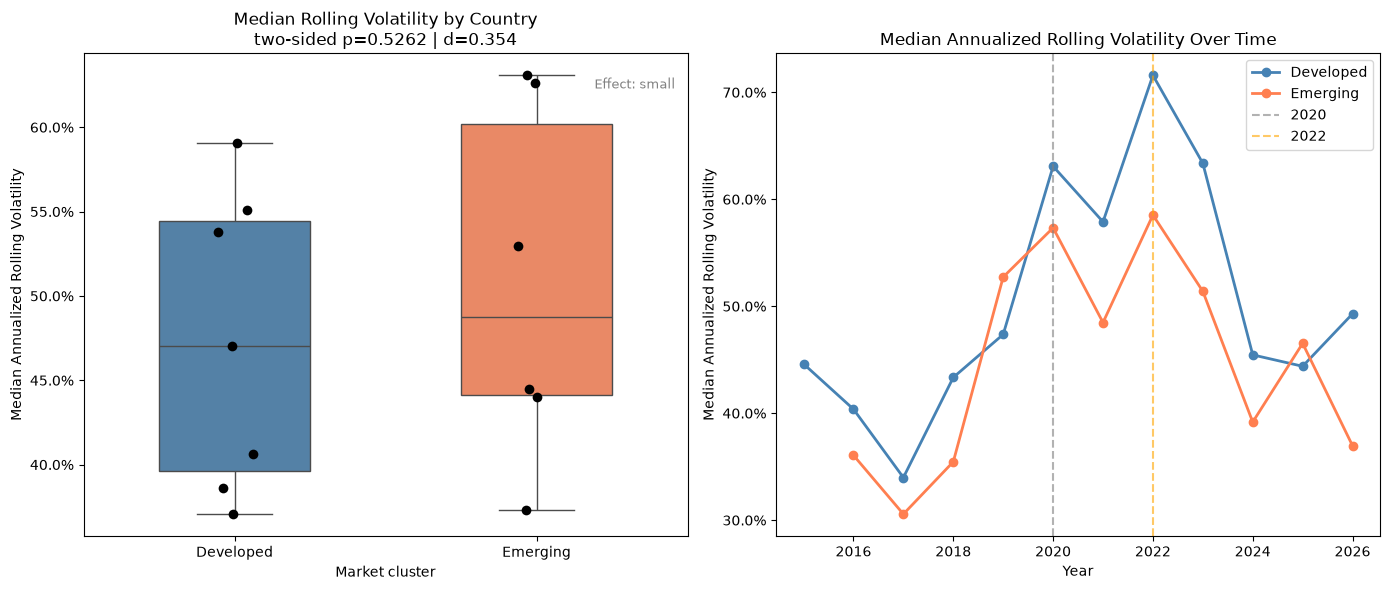

In [ ]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

order = ["Developed", "Emerging"]




sns.boxplot(
    data=vol_per_country,
    x="market_type",
    y="rolling_vol",
    order=order,
    hue="market_type",
    palette={
        "Developed": "steelblue",
        "Emerging": "coral"
    },
    legend=False,
    width=0.5,
    ax=axes[0]
)

sns.stripplot(
    data=vol_per_country,
    x="market_type",
    y="rolling_vol",
    order=order,
    color="black",
    size=7,
    jitter=0.08,
    ax=axes[0]
)

axes[0].set_title(
    "Median Rolling Volatility by Country\n"
    f"two-sided p={p_value_two_sided:.4f} | "
    f"d={d:.3f}"
)

axes[0].set_xlabel("Market cluster")
axes[0].set_ylabel(
    "Median Annualized Rolling Volatility"
)

axes[0].yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)



for market_type, color in [
    ("Developed", "steelblue"),
    ("Emerging", "coral")
]:
    data = vol_by_year[
        vol_by_year["market_type"] == market_type
    ]

    axes[1].plot(
        data["year"],
        data["rolling_vol"],
        color=color,
        linewidth=2,
        marker="o",
        label=market_type
    )


axes[1].axvline(
    2020,
    color="gray",
    linestyle="--",
    alpha=0.6,
    label="2020"
)

axes[1].axvline(
    2022,
    color="orange",
    linestyle="--",
    alpha=0.6,
    label="2022"
)

axes[1].set_title(
    "Median Annualized Rolling Volatility Over Time"
)

axes[1].set_xlabel("Year")
axes[1].set_ylabel(
    "Median Annualized Rolling Volatility"
)

axes[1].yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

axes[1].legend()


abs_d = abs(d)

if abs_d < 0.2:
    effect = "negligible"
elif abs_d < 0.5:
    effect = "small"
elif abs_d < 0.8:
    effect = "medium"
else:
    effect = "large"

axes[0].text(
    0.98,
    0.95,
    f"Effect: {effect}",
    transform=axes[0].transAxes,
    fontsize=9,
    ha="right",
    va="top",
    color="gray"
)

plt.tight_layout()
plt.show()